<a href="https://colab.research.google.com/github/Bivasgithub/Sea_Breeze_Front/blob/main/Naor_verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ===============================
# 1. Load Data
# ===============================
file_path1 = "/content/Ashdod_data.xlsx"  # change path if needed

df = pd.read_excel(file_path1, engine="openpyxl")
# ===============================
# 2. Inspect & Rename Columns
# ===============================
#print(df.head())
#print(df["Wind direction (°)"])
#df1=df[["Date & Time (UTC)","Gust wind speed (m/s)"]]
#print(df["Wind direction (°)"].isnull().sum())


# Clean column names
df.columns = df.columns.str.strip()

df["Wind direction (°)"] = pd.to_numeric(df["Wind direction (°)"], errors="coerce")
df["Wind speed (m/s)"] = pd.to_numeric(df["Wind speed (m/s)"], errors="coerce")

# Drop NaN rows
#df = df.dropna(subset=["Wind direction (°)", "Wind speed (m/s)"])

# Now apply deg2rad
theta = np.deg2rad(df["Wind direction (°)"].values)
V = df["Wind speed (m/s)"].values

# Compute components
u = -V * np.sin(theta)
v = -V * np.cos(theta)

df["u"] = u
df["v"] = v

df["V_onshore"] = u

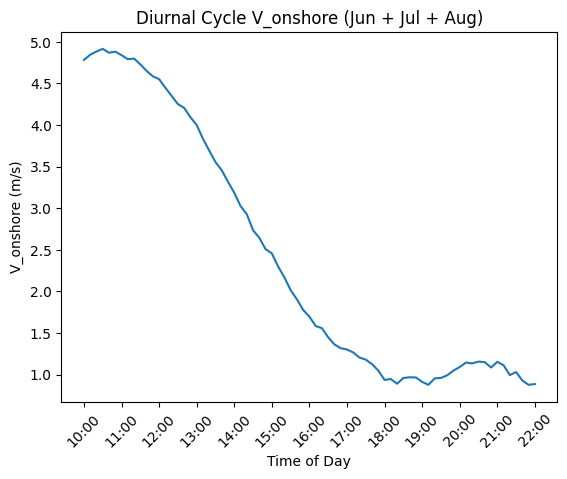

In [ ]:
df=df[["Date & Time (UTC)","V_onshore"]]

# Clean column names
df.columns = df.columns.str.strip()
# Convert datetime
df['Date & Time (UTC)'] = pd.to_datetime(df['Date & Time (UTC)'], dayfirst=True)

# Set index
df.set_index('Date & Time (UTC)', inplace=True)
# Slice the dataset
df_s = df[df.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

# Time Index
df_s["time"] = df_s.index.time
df_s["time"] = df_s.index.strftime("%H:%M")
mean_d = df_s.groupby("time")["V_onshore"].mean()
mean_d = mean_d.sort_index()

# Diurnal Cycle of Wind Speed plot
import matplotlib.pyplot as plt
plt.plot(mean_d.index, mean_d.values)
#plt.xticks(rotation=45)
plt.xticks(mean_d.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("V_onshore (m/s)")
plt.title("Diurnal Cycle V_onshore (Jun + Jul + Aug)")
plt.show()

In [ ]:
#print(df1.head())

# **V_onshore component of velocity**

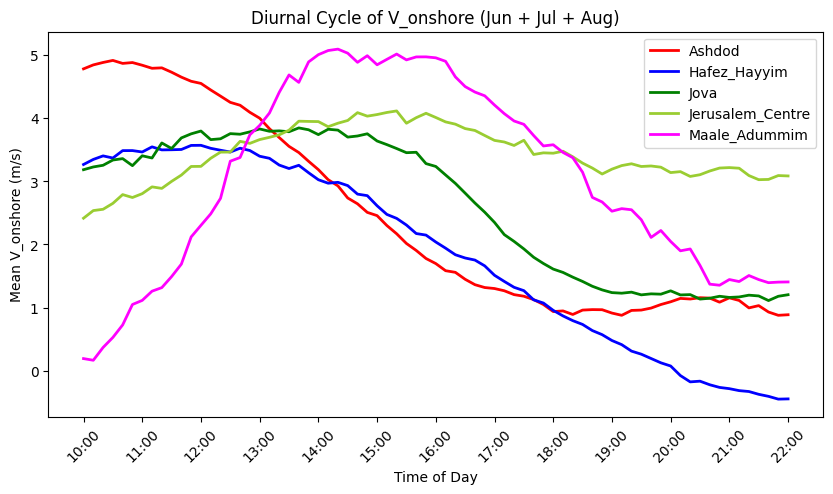

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_V_onshore(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Clean column names
    df.columns = df.columns.str.strip()

    df["Wind direction (°)"] = pd.to_numeric(df["Wind direction (°)"], errors="coerce")
    df["Wind speed (m/s)"] = pd.to_numeric(df["Wind speed (m/s)"], errors="coerce")


    # Now apply deg2rad
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    # Compute components
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    df["V_onshore"] = u

    df=df[["Date & Time (UTC)","V_onshore"]]

    # Clean column names
    df.columns = df.columns.str.strip()
    # Convert datetime
    df['Date & Time (UTC)'] = pd.to_datetime(df['Date & Time (UTC)'], dayfirst=True)
    # Set index
    df.set_index('Date & Time (UTC)', inplace=True)
    # Slice the dataset
    df_s = df[df.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Time Index
    df_s["time"] = df_s.index.time
    df_s["time"] = df_s.index.strftime("%H:%M")
    mean_d = df_s.groupby("time")["V_onshore"].mean()
    mean_d = mean_d.sort_index()

    return mean_d


# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Station names
stations = ["Ashdod", "Hafez_Hayyim", "Jova", "Jerusalem_Centre", "Maale_Adummim"]

# Compute diurnal cycles
mean1 = compute_V_onshore(file_path1)
mean2 = compute_V_onshore(file_path2)
mean3 = compute_V_onshore(file_path3)
mean4 = compute_V_onshore(file_path4)
mean5 = compute_V_onshore(file_path5)


plt.figure(figsize=(10,5))
plt.plot(mean1.index, mean1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(mean2.index, mean2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(mean3.index, mean3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(mean4.index, mean4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(mean5.index, mean5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")

plt.xticks(mean1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean V_onshore (m/s)")
plt.title("Diurnal Cycle of V_onshore (Jun + Jul + Aug)")

plt.legend()
# plt.grid(True)

plt.savefig("Mean_V_onshore.png", dpi=300, bbox_inches='tight')
plt.show()

# **Code for one day 10th July**

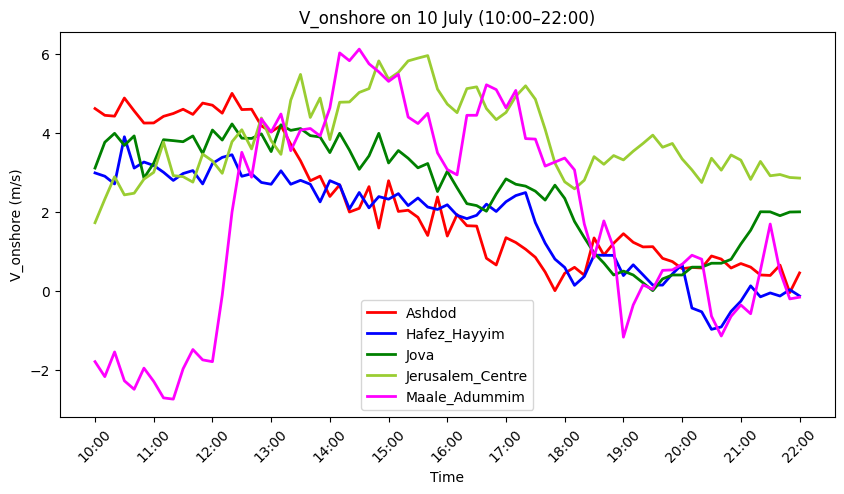

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station for 10 July only
def compute_V_onshore_single_day(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Clean column names
    df.columns = df.columns.str.strip()

    df["Wind direction (°)"] = pd.to_numeric(df["Wind direction (°)"], errors="coerce")
    df["Wind speed (m/s)"] = pd.to_numeric(df["Wind speed (m/s)"], errors="coerce")

    # Convert to radians
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    # Wind components
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v
    df["V_onshore"] = u

    df = df[["Date & Time (UTC)", "V_onshore"]]

    # Convert datetime
    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    # ✅ Filter ONLY 10 July (any year)
    df_s = df[
        (df.index.month == 7) &
        (df.index.day == 10)
    ].between_time("10:00", "22:00")

    return df_s


# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Compute for each station
df1 = compute_V_onshore_single_day(file_path1)
df2 = compute_V_onshore_single_day(file_path2)
df3 = compute_V_onshore_single_day(file_path3)
df4 = compute_V_onshore_single_day(file_path4)
df5 = compute_V_onshore_single_day(file_path5)

# Format x-axis to show only time (HH:MM)
time_labels = df1.index.strftime("%H:%M")


plt.figure(figsize=(10,5))

plt.plot(df1.index, df1["V_onshore"], linewidth=2, color='red', label="Ashdod")
plt.plot(df2.index, df2["V_onshore"], linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(df3.index, df3["V_onshore"], linewidth=2, color='green', label="Jova")
plt.plot(df4.index, df4["V_onshore"], linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(df5.index, df5["V_onshore"], linewidth=2, color='magenta', label="Maale_Adummim")

plt.xticks(df1.index[::6], time_labels[::6], rotation=45)
#plt.xticks(rotation=45)
plt.xlabel("Time")
plt.ylabel("V_onshore (m/s)")
plt.title("V_onshore on 10 July (10:00–22:00)")

plt.legend()
plt.savefig("V_onshore_10_July.png", dpi=300, bbox_inches='tight')
plt.show()

# **Hourly rate of Change of V_onshore**

<Figure size 1000x500 with 0 Axes>

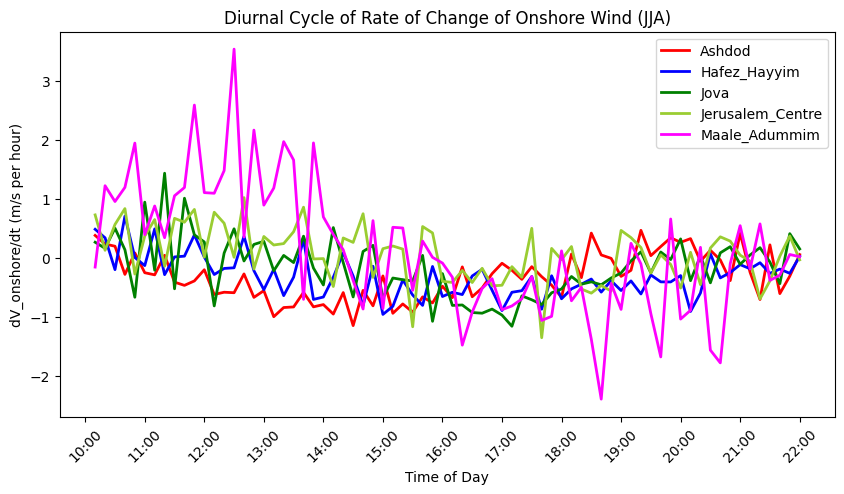

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Step 1: Compute diurnal mean V_onshore
# ==============================
def compute_V_onshore_diurnal(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Clean column names
    df.columns = df.columns.str.strip()

    df["Wind direction (°)"] = pd.to_numeric(df["Wind direction (°)"], errors="coerce")
    df["Wind speed (m/s)"] = pd.to_numeric(df["Wind speed (m/s)"], errors="coerce")

    # Drop NaNs
    df = df.dropna(subset=["Wind direction (°)", "Wind speed (m/s)"])

    # Convert datetime
    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    # Compute wind components
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    df["V_onshore"] = u

    # JJA + daytime filtering
    df_s = df[df.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Time of day grouping
    df_s["time"] = df_s.index.strftime("%H:%M")

    mean_d = df_s.groupby("time")["V_onshore"].mean().sort_index()

    return mean_d


def compute_rate_of_change(mean_series):
    # backward difference (10-min data → hourly rate)
    dV_dt = (mean_series - mean_series.shift(1)) * 6
    return dV_dt


# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Step 3: Compute diurnal means
mean1 = compute_V_onshore_diurnal(file_path1)
mean2 = compute_V_onshore_diurnal(file_path2)
mean3 = compute_V_onshore_diurnal(file_path3)
mean4 = compute_V_onshore_diurnal(file_path4)
mean5 = compute_V_onshore_diurnal(file_path5)

# Step 4: Compute rate of change
rate1 = compute_rate_of_change(mean1)
rate2 = compute_rate_of_change(mean2)
rate3 = compute_rate_of_change(mean3)
rate4 = compute_rate_of_change(mean4)
rate5 = compute_rate_of_change(mean5)

# Step 5: Plot
plt.figure(figsize=(10,5))

plt.figure(figsize=(10,5))
plt.plot(rate1.index, rate1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(rate2.index, rate2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(rate3.index, rate3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(rate4.index, rate4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(rate5.index, rate5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")

plt.xticks(rate1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("dV_onshore/dt (m/s per hour)")
plt.title("Diurnal Cycle of Rate of Change of Onshore Wind (JJA)")

plt.legend()
plt.savefig("dV_onshore_dt.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Load Data
file_path1 = "/content/Ashdod_data.xlsx"  # change path if needed
df = pd.read_excel(file_path1, engine="openpyxl")

import numpy as np
import pandas as pd

# Convert required columns to numeric
df["Temperature (°C)"] = pd.to_numeric(df["Temperature (°C)"], errors="coerce")
df["Relative humidity (%)"] = pd.to_numeric(df["Relative humidity (%)"], errors="coerce")

# Drop NaNs (important)
df = df.dropna(subset=["Temperature (°C)", "Relative humidity (%)"])

# Convert temp to Kelvin
T_K = df["Temperature (°C)"] + 273.15

# Constants
A = 2.53e7   # hPa
B = 5420     # K
R = 287
Rv = 461
p = 920      # constant pressure

# Compute specific humidity
df["q"] = (df["Relative humidity (%)"] / 100.0) * (R / Rv) * (A / p) * np.exp(-B / T_K)
# Convert to g/kg
df["q_gkg"] = df["q"] * 1000

df2=df[["Date & Time (UTC)","q_gkg"]]

# Clean column names
df2.columns = df1.columns.str.strip()
# Convert datetime
df2['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)

# Set index
df2.set_index('Date & Time (UTC)', inplace=True)
# Slice the dataset
df_s = df2[df2.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

# Time Index
df_s["time"] = df_s.index.time
df_s["time"] = df_s.index.strftime("%H:%M")
mean_d = df_s.groupby("time")["Wind speed (m/s)"].mean()
mean_d = mean_d.sort_index()


# Diurnal Cycle of Wind Speed plot
import matplotlib.pyplot as plt
plt.plot(mean_d.index, mean_d.values)
#plt.xticks(rotation=45)
plt.xticks(mean_d.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Specific Humidity (g/kg)")
plt.title("Diurnal Cycle Specific Humidity (Jun + Jul + Aug)")
plt.show()

/tmp/ipykernel_12091/2930568043.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["q"] = (df["Relative humidity (%)"] / 100.0) * (R / Rv) * (A / p) * np.exp(-B / T_K)
/tmp/ipykernel_12091/2930568043.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["q_gkg"] = df["q"] * 1000


In [ ]:
print(df["q_gkg"].mean())

0.1322243309008222


/tmp/ipykernel_12091/78320529.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)


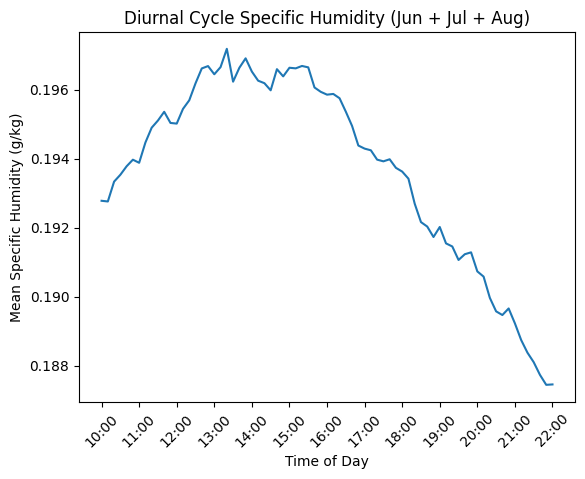

In [ ]:
df2=df[["Date & Time (UTC)","q_gkg"]]

# Clean column names
df2.columns = df1.columns.str.strip()
# Convert datetime
df2['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)

# Set index
df2.set_index('Date & Time (UTC)', inplace=True)
# Slice the dataset
df_s = df2[df2.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

# Time Index
df_s["time"] = df_s.index.time
df_s["time"] = df_s.index.strftime("%H:%M")
mean_d = df_s.groupby("time")["Wind speed (m/s)"].mean()
mean_d = mean_d.sort_index()


# Diurnal Cycle of Wind Speed plot
import matplotlib.pyplot as plt
plt.plot(mean_d.index, mean_d.values)
#plt.xticks(rotation=45)
plt.xticks(mean_d.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Specific Humidity (g/kg)")
plt.title("Diurnal Cycle Specific Humidity (Jun + Jul + Aug)")
plt.show()

/tmp/ipykernel_1187/467234546.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
/tmp/ipykernel_1187/467234546.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")
/tmp/ipykernel_1187/467234546.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

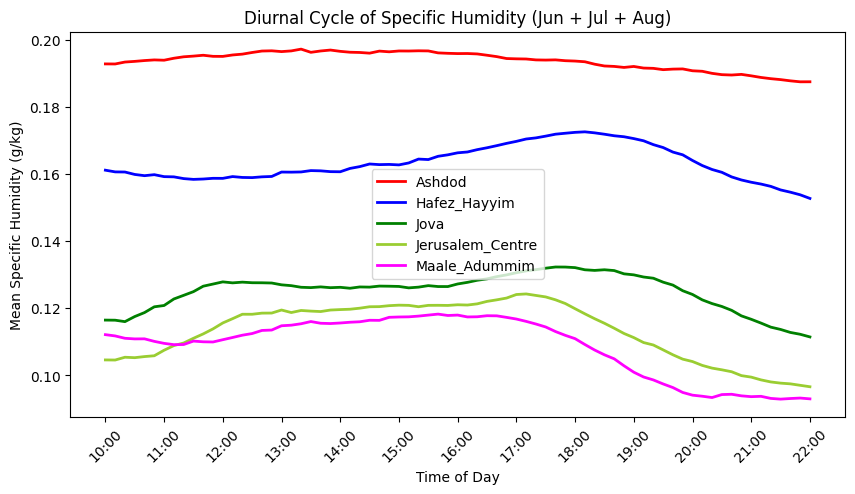

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_diurnal(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")
    # Select required columns
    df1 = df[["Date & Time (UTC)", "Temperature (°C)", "Relative humidity (%)"]]
    df1.columns = df1.columns.str.strip()
    # Convert to numeric
    df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
    df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna(subset=["Temperature (°C)", "Relative humidity (%)"])
    # Convert temperature to Kelvin
    T_K = df1["Temperature (°C)"] + 273.15

    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    # Compute specific humidity
    df1["q"] = (df1["Relative humidity (%)"] / 100.0) * (R / Rv) * (A / p) * np.exp(-B / T_K)
    df1["q_gkg"] = df1["q"] * 1000
    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)
    # Filter months and time
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Compute mean diurnal cycle (IMPORTANT CHANGE)
    mean_diurnal = df_selected.groupby("time")["q_gkg"].mean()
    mean_diurnal = mean_diurnal.sort_index()

    return mean_diurnal


# File paths for stations
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Diurnal cycles
mean_diurnal1 = compute_diurnal(file_path1)
mean_diurnal2 = compute_diurnal(file_path2)
mean_diurnal3 = compute_diurnal(file_path3)
mean_diurnal4 = compute_diurnal(file_path4)
mean_diurnal5 = compute_diurnal(file_path5)


# Plot all stations
plt.figure(figsize=(10,5))

plt.plot(mean_diurnal1.index, mean_diurnal1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(mean_diurnal2.index, mean_diurnal2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(mean_diurnal3.index, mean_diurnal3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(mean_diurnal4.index, mean_diurnal4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(mean_diurnal5.index, mean_diurnal5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")


plt.xticks(mean_diurnal1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Specific Humidity (g/kg)")
plt.title("Diurnal Cycle of Specific Humidity (Jun + Jul + Aug)")

plt.legend()
# plt.grid(True)

plt.savefig("Mean_specific_humidity.png", dpi=300, bbox_inches='tight')
plt.show()

# **Hourly rate of change in Specific Humidity**

/tmp/ipykernel_21431/453687035.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
/tmp/ipykernel_21431/453687035.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")
/tmp/ipykernel_21431/453687035.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

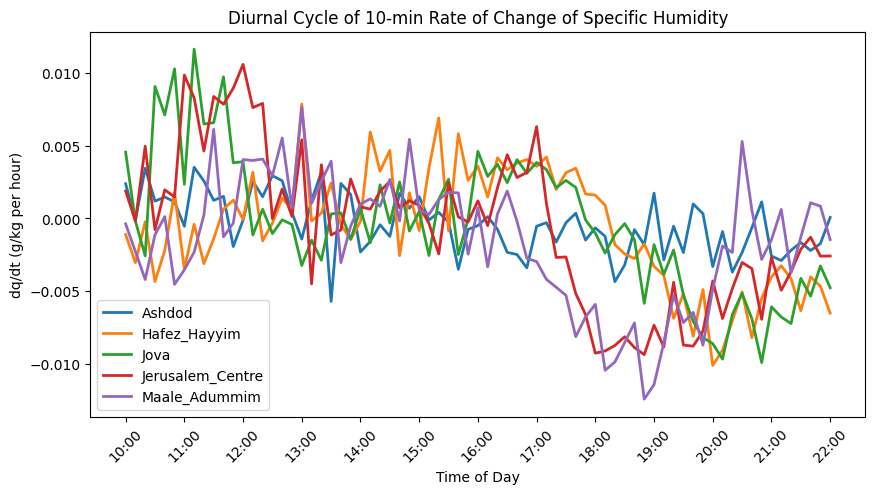

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_diurnal_rate(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns
    df1 = df[["Date & Time (UTC)", "Temperature (°C)", "Relative humidity (%)"]]
    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
    df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna(subset=["Temperature (°C)", "Relative humidity (%)"])

    # Convert temperature to Kelvin
    T_K = df1["Temperature (°C)"] + 273.15

    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    # Compute specific humidity
    df1["q"] = (df1["Relative humidity (%)"] / 100.0) * (R / Rv) * (A / p) * np.exp(-B / T_K)
    df1["q_gkg"] = df1["q"] * 1000

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Sort index (VERY IMPORTANT for backward difference)
    df1 = df1.sort_index()

    # ==========================
    # BACKWARD DIFFERENCE (10 min)
    # ==========================
    df1["dq_dt"] = (df1["q_gkg"] - df1["q_gkg"].shift(1)) * 6
    # (×6 converts 10-min change → per hour)

    # Remove NaN from first shift
    df1 = df1.dropna(subset=["dq_dt"])

    # Filter months and time
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Mean diurnal of rate
    mean_diurnal_rate = df_selected.groupby("time")["dq_dt"].mean()
    mean_diurnal_rate = mean_diurnal_rate.sort_index()

    return mean_diurnal_rate


# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Compute diurnal rate
rate1 = compute_diurnal_rate(file_path1)
rate2 = compute_diurnal_rate(file_path2)
rate3 = compute_diurnal_rate(file_path3)
rate4 = compute_diurnal_rate(file_path4)
rate5 = compute_diurnal_rate(file_path5)

# ==========================
# Plot
# ==========================
plt.figure(figsize=(10,5))

plt.plot(rate1.index, rate1.values, linewidth=2, label="Ashdod")
plt.plot(rate2.index, rate2.values, linewidth=2, label="Hafez_Hayyim")
plt.plot(rate3.index, rate3.values, linewidth=2, label="Jova")
plt.plot(rate4.index, rate4.values, linewidth=2, label="Jerusalem_Centre")
plt.plot(rate5.index, rate5.values, linewidth=2, label="Maale_Adummim")

plt.xticks(rate1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("dq/dt (g/kg per hour)")
plt.title("Diurnal Cycle of 10-min Rate of Change of Specific Humidity")

plt.legend()
plt.savefig("dq_dt_diurnal.png", dpi=300, bbox_inches='tight')
plt.show()

# **Mean Relative Humidity changes**

/tmp/ipykernel_1187/869542063.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")
/tmp/ipykernel_1187/869542063.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")
/tmp/ipykernel_1187/869542063.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

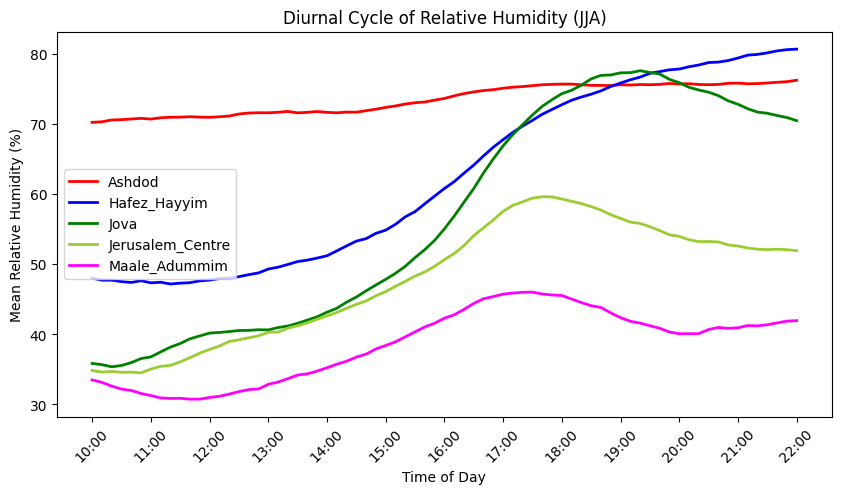

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_diurnal_RH(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns
    df1 = df[["Date & Time (UTC)", "Relative humidity (%)"]]
    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna(subset=["Relative humidity (%)"])

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Filter months (JJA) and daytime
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Compute mean diurnal cycle of RH
    mean_diurnal = df_selected.groupby("time")["Relative humidity (%)"].mean()
    mean_diurnal = mean_diurnal.sort_index()

    return mean_diurnal

# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Compute RH diurnal cycles
rh1 = compute_diurnal_RH(file_path1)
rh2 = compute_diurnal_RH(file_path2)
rh3 = compute_diurnal_RH(file_path3)
rh4 = compute_diurnal_RH(file_path4)
rh5 = compute_diurnal_RH(file_path5)

# Plot
plt.figure(figsize=(10,5))
plt.plot(rh1.index, rh1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(rh2.index, rh2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(rh3.index, rh3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(rh4.index, rh4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(rh5.index, rh5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")


plt.xticks(rh1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Relative Humidity (%)")
plt.title("Diurnal Cycle of Relative Humidity (JJA)")

plt.legend()
plt.savefig("Mean_relative_humidity.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Mean Specific Humidity using new formula

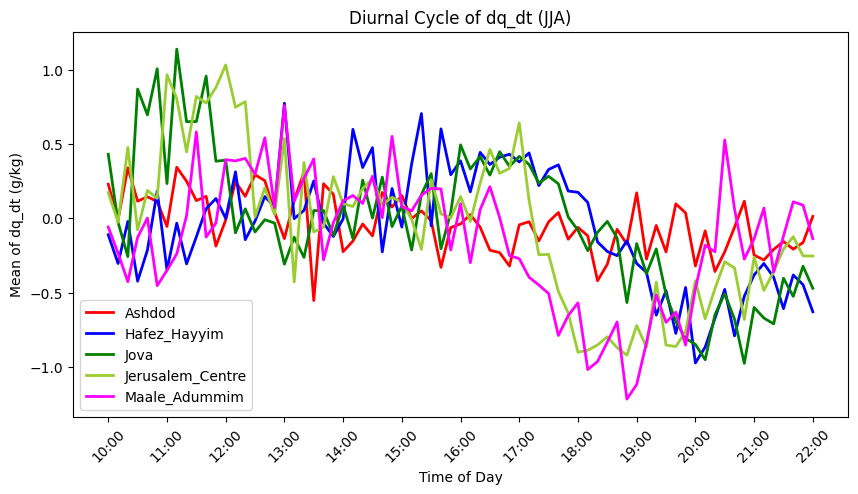

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_diurnal(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select + clean
    df = df[["Date & Time (UTC)", "Temperature (°C)", "Relative humidity (%)"]].copy()
    df.columns = df.columns.str.strip()

    # Convert to numeric
    df["Temperature (°C)"] = pd.to_numeric(df["Temperature (°C)"], errors="coerce")
    df["Relative humidity (%)"] = pd.to_numeric(df["Relative humidity (%)"], errors="coerce")
    df = df.dropna()

    # ---- Specific Humidity (Tetens) ----
    p = 920  # hPa
    T = df["Temperature (°C)"]

    e_s = 6.112 * np.exp((17.67 * T) / (T + 243.5))        # saturation vapor pressure
    e = (df["Relative humidity (%)"] / 100.0) * e_s        # actual vapor pressure
    df["q_gkg"] = (0.622 * e / p) * 1000                   # g/kg

    df["dq_gkg_dt"] = (df["q_gkg"] - df["q_gkg"].shift(1)) * 6

    # ---- Time handling ----
    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    df = df[df.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")
    df["time"] = df.index.strftime("%H:%M")

    mean_diurnal_rate = df.groupby("time")["dq_gkg_dt"].mean().sort_index()

    return mean_diurnal_rate


# # ==========================
#     # BACKWARD DIFFERENCE (10 min)
#     # ==========================
#     df1["dq_dt"] = (df1["q_gkg"] - df1["q_gkg"].shift(1)) * 6
#     # (×6 converts 10-min change → per hour)

#     # Remove NaN from first shift
#     df1 = df1.dropna(subset=["dq_dt"])

#     # Filter months and time
#     df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

#     # Create time column
#     df_selected["time"] = df_selected.index.strftime("%H:%M")

#     # Mean diurnal of rate
#     mean_diurnal_rate = df_selected.groupby("time")["dq_dt"].mean()
#     mean_diurnal_rate = mean_diurnal_rate.sort_index()

#     return mean_diurnal_rate


# File paths for stations
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Diurnal cycles
mean_diurnal1 = compute_diurnal(file_path1)
mean_diurnal2 = compute_diurnal(file_path2)
mean_diurnal3 = compute_diurnal(file_path3)
mean_diurnal4 = compute_diurnal(file_path4)
mean_diurnal5 = compute_diurnal(file_path5)


# Plot all stations
plt.figure(figsize=(10,5))

plt.plot(mean_diurnal1.index, mean_diurnal1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(mean_diurnal2.index, mean_diurnal2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(mean_diurnal3.index, mean_diurnal3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(mean_diurnal4.index, mean_diurnal4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(mean_diurnal5.index, mean_diurnal5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")


plt.xticks(mean_diurnal1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean of dq_dt (g/kg)")
plt.title("Diurnal Cycle of dq_dt (JJA)")

plt.legend()
# plt.grid(True)

plt.savefig("Mean_dq_dt_nw.png", dpi=300, bbox_inches='tight')
plt.show()

# **Mean Hourly changes of RH**

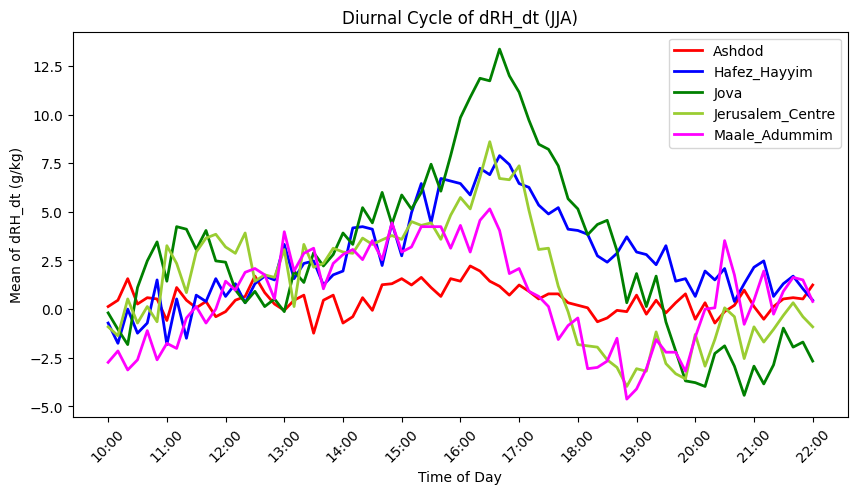

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_diurnal(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select + clean
    df = df[["Date & Time (UTC)", "Temperature (°C)", "Relative humidity (%)"]].copy()
    df.columns = df.columns.str.strip()

    # Convert to numeric
    df["Temperature (°C)"] = pd.to_numeric(df["Temperature (°C)"], errors="coerce")
    df["Relative humidity (%)"] = pd.to_numeric(df["Relative humidity (%)"], errors="coerce")
    df = df.dropna()

    # ---- Specific Humidity (Tetens) ----
    #p = 920  # hPa
    #T = df["Temperature (°C)"]

    #e_s = 6.112 * np.exp((17.67 * T) / (T + 243.5))        # saturation vapor pressure
    df["RH"] = df["Relative humidity (%)"]        # actual vapor pressure
    #df["q_gkg"] = (0.622 * e / p) * 1000                   # g/kg

    df["dRH_dt"] = (df["RH"] - df["RH"].shift(1)) * 6

    # ---- Time handling ----
    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    df = df[df.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")
    df["time"] = df.index.strftime("%H:%M")

    mean_diurnal_rate = df.groupby("time")["dRH_dt"].mean().sort_index()

    return mean_diurnal_rate


# File paths for stations
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Diurnal cycles
mean_diurnal1 = compute_diurnal(file_path1)
mean_diurnal2 = compute_diurnal(file_path2)
mean_diurnal3 = compute_diurnal(file_path3)
mean_diurnal4 = compute_diurnal(file_path4)
mean_diurnal5 = compute_diurnal(file_path5)


# Plot all stations
plt.figure(figsize=(10,5))

plt.plot(mean_diurnal1.index, mean_diurnal1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(mean_diurnal2.index, mean_diurnal2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(mean_diurnal3.index, mean_diurnal3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(mean_diurnal4.index, mean_diurnal4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(mean_diurnal5.index, mean_diurnal5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")


plt.xticks(mean_diurnal1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean of dRH_dt (g/kg)")
plt.title("Diurnal Cycle of dRH_dt (JJA)")

plt.legend()
# plt.grid(True)

plt.savefig("Mean_dRH_dt_nw.png", dpi=300, bbox_inches='tight')
plt.show()

# **d(RH)/dt Derivative od Relative Humidity**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_diurnal_RH(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns
    df1 = df[["Date & Time (UTC)", "Relative humidity (%)"]]
    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna(subset=["Relative humidity (%)"])

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Filter months (JJA) and daytime
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Compute mean diurnal cycle of RH
    mean_diurnal = df_selected.groupby("time")["Relative humidity (%)"].mean()
    mean_diurnal = mean_diurnal.sort_index()

    return mean_diurnal

# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Compute RH diurnal cycles
rh1 = compute_diurnal_RH(file_path1)
rh2 = compute_diurnal_RH(file_path2)
rh3 = compute_diurnal_RH(file_path3)
rh4 = compute_diurnal_RH(file_path4)
rh5 = compute_diurnal_RH(file_path5)

# Plot
plt.figure(figsize=(10,5))
plt.plot(rh1.index, rh1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(rh2.index, rh2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(rh3.index, rh3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(rh4.index, rh4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(rh5.index, rh5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")


plt.xticks(rh1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Relative Humidity (%)")
plt.title("Diurnal Cycle of Relative Humidity (JJA)")

plt.legend()
plt.savefig("Mean_relative_humidity.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_21431/1923042259.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
/tmp/ipykernel_21431/1923042259.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")


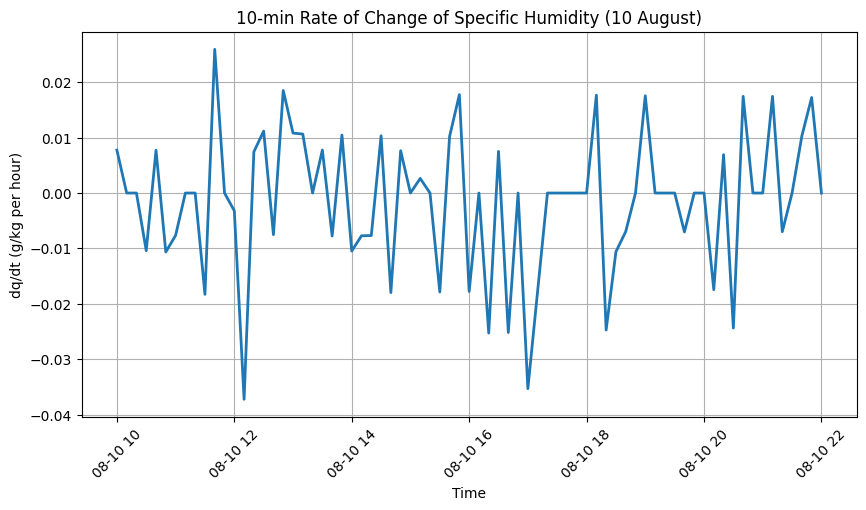

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_single_day_rate(file_path):

    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns
    df1 = df[["Date & Time (UTC)", "Temperature (°C)", "Relative humidity (%)"]]
    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
    df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna(subset=["Temperature (°C)", "Relative humidity (%)"])

    # Convert temperature to Kelvin
    T_K = df1["Temperature (°C)"] + 273.15

    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    # Compute specific humidity
    df1["q"] = (df1["Relative humidity (%)"] / 100.0) * (R / Rv) * (A / p) * np.exp(-B / T_K)
    df1["q_gkg"] = df1["q"] * 1000

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Sort (important)
    df1 = df1.sort_index()

    # ==========================
    # Backward difference (10-min)
    # ==========================
    df1["dq_dt"] = (df1["q_gkg"] - df1["q_gkg"].shift(1)) * 6  # g/kg per hour

    # Remove NaN
    df1 = df1.dropna(subset=["dq_dt"])

    # ==========================
    # Filter ONLY 10 August
    # ==========================
    df_day = df1[(df1.index.month == 8) & (df1.index.day == 10)]

    # Optional: restrict time window
    df_day = df_day.between_time("10:00", "22:00")

    # ==========================
    # Plot
    # ==========================
    plt.figure(figsize=(10,5))

    plt.plot(df_day.index, df_day["dq_dt"], linewidth=2)

    plt.xlabel("Time")
    plt.ylabel("dq/dt (g/kg per hour)")
    plt.title("10-min Rate of Change of Specific Humidity (10 August)")

    plt.xticks(rotation=45)
    plt.grid(True)

    plt.savefig("dq_dt_10_august.png", dpi=300, bbox_inches='tight')
    plt.show()


# Example usage
file_path = "/content/Ashdod_data.xlsx"
plot_single_day_rate(file_path)

In [ ]:
import numpy as np

import pandas as pd
import numpy as np

cols = [
    "Temperature (°C)",
    "Relative humidity (%)",
    "Pressure at station level (hPa)"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert temperature to Kelvin
T_K = df["Temperature (°C)"] + 273.15

# # Constants
# A = 2.53e7   # hPa
# B = 5420     # K
# R = 287
# Rv = 461

# # Compute specific humidity
# df["q_alt"] = (df["Relative humidity (%)"] / 100.0) * (R / Rv) * (A / df["Pressure at station level (hPa)"]) * np.exp(-B / T_K)

# # Convert to g/kg
# df["q_alt_gkg"] = df["q_alt"] * 1000

KeyError: 'Pressure at station level (hPa)'

In [ ]:
# Clean column names
df1.columns = df1.columns.str.strip()

# Convert datetime
df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)

# Set index
df1.set_index('Date & Time (UTC)', inplace=True)


/tmp/ipykernel_6335/205678460.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)


In [ ]:
print(df1.index.month.unique())

Index([4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3], dtype='int32', name='Date & Time (UTC)')


In [ ]:
#df_june = df1[df1.index.month == 6 ].between_time("10:00", "22:00")
df_selected = df1[df1.index.month.isin([6, 7, 10])].between_time("10:00", "22:00")

In [ ]:
df_selected["time"] = df_selected.index.time
df_selected["time"] = df_selected.index.strftime("%H:%M")
mean_diurnal = df_selected.groupby("time")["Wind speed (m/s)"].mean()

mean_diurnal = mean_diurnal.sort_index()

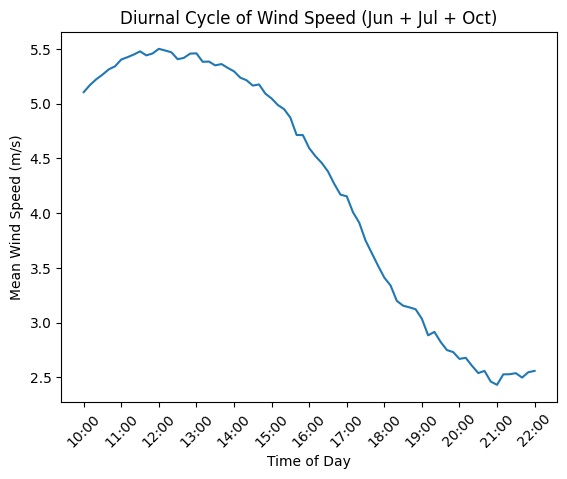

In [ ]:
import matplotlib.pyplot as plt

plt.plot(mean_diurnal.index, mean_diurnal.values)
#plt.xticks(rotation=45)
plt.xticks(mean_diurnal.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Wind Speed (m/s)")
plt.title("Diurnal Cycle of Wind Speed (Jun + Jul + Oct)")
plt.show()

In [ ]:
mean_diurnal

,Wind speed (m/s)
time,
10:00,5.104348
10:10,5.169565
10:20,5.221739
10:30,5.26413
10:40,5.311957
...,...
21:20,2.528261
21:30,2.538043
21:40,2.497826


/tmp/ipykernel_6335/2907856369.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)


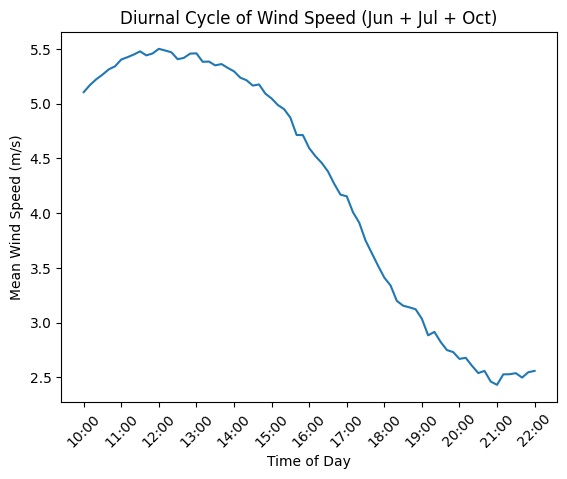

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# 1. Load Data
file_path1 = "/content/Ashdod_data.xlsx"  # change path if needed

df = pd.read_excel(file_path1, engine="openpyxl")
# ===============================
# 2. Inspect & Rename Columns
# ===============================
df1=df[["Date & Time (UTC)","Wind speed (m/s)"]]


# Clean column names
df1.columns = df1.columns.str.strip()
# Convert datetime
df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)

# Set index
df1.set_index('Date & Time (UTC)', inplace=True)
# Slice the dataset
df_selected = df1[df1.index.month.isin([6, 7, 10])].between_time("10:00", "22:00")

# Time Index
df_selected["time"] = df_selected.index.time
df_selected["time"] = df_selected.index.strftime("%H:%M")
mean_diurnal = df_selected.groupby("time")["Wind speed (m/s)"].mean()
mean_diurnal = mean_diurnal.sort_index()


# Diurnal Cycle of Wind Speed plot
import matplotlib.pyplot as plt
plt.plot(mean_diurnal.index, mean_diurnal.values)
#plt.xticks(rotation=45)
plt.xticks(mean_diurnal.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Wind Speed (m/s)")
plt.title("Diurnal Cycle of Wind Speed (Jun + Jul + Oct)")
plt.show()

# **For Two Station I plotted here**

/tmp/ipykernel_4405/3026807970.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
/tmp/ipykernel_4405/3026807970.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
/tmp/ipykernel_4405/3026807970.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

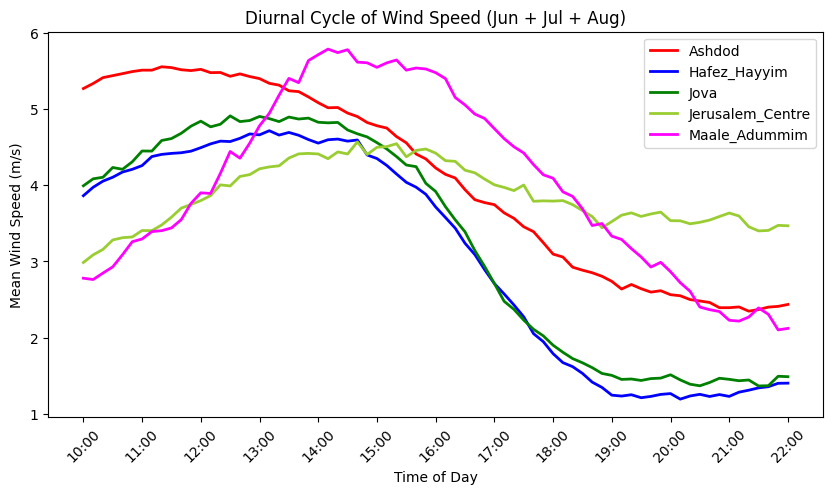

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def compute_wind_single_day(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    df1 = df[["Date & Time (UTC)", "Wind speed (m/s)"]].copy()
    df1.columns = df1.columns.str.strip()

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # ✅ Filter ONLY 10 July
    df_selected = df1[
        (df1.index.month == 7) &
        (df1.index.day == 10)
    ].between_time("10:00", "22:00")

    return df_selected

# File paths for two stations

file_path1 = "/content/Ashdod_data.xlsx"
#file_path2 = "/content/Jerusalem_Givat_Ram_data.xlsx"   # <-- change this
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Compute diurnal cycles
# ===============================
mean_diurnal1 = compute_diurnal(file_path1)
mean_diurnal2 = compute_diurnal(file_path2)
mean_diurnal3 = compute_diurnal(file_path3)
mean_diurnal4 = compute_diurnal(file_path4)
mean_diurnal5 = compute_diurnal(file_path5)

# Plot both in one graph
# ===============================
plt.figure(figsize=(10,5))

plt.plot(mean_diurnal1.index, mean_diurnal1.values, marker='None', linestyle='-', color='red', linewidth=2, label="Ashdod")
plt.plot(mean_diurnal2.index, mean_diurnal2.values, marker='None', linestyle='-', color='blue', linewidth=2, label="Hafez_Hayyim")
plt.plot(mean_diurnal3.index, mean_diurnal3.values, marker='None', linestyle='-', color='green', linewidth=2, label="Jova")
plt.plot(mean_diurnal4.index, mean_diurnal4.values, marker='None', linestyle='-', color='yellowgreen', linewidth=2, label="Jerusalem_Centre")
plt.plot(mean_diurnal5.index, mean_diurnal5.values, marker='None', linestyle='-', color='magenta', linewidth=2, label="Maale_Adummim")

plt.xticks(mean_diurnal1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Wind Speed (m/s)")
plt.title("Diurnal Cycle of Wind Speed (Jun + Jul + Aug)")

plt.legend()
#plt.grid(True)
plt.savefig("Mean_wind_speed.png", dpi=300, bbox_inches='tight')
plt.show()

# **For Single Day wind Speed (10th July)**

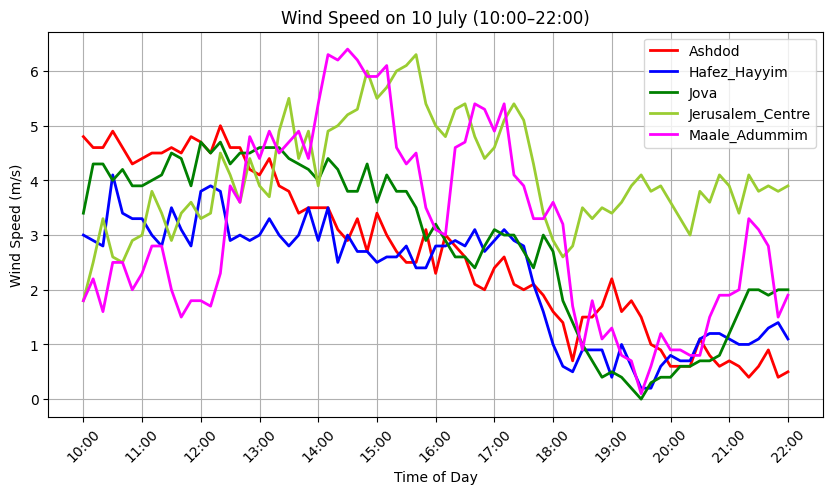

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_wind_single_day(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    df1 = df[["Date & Time (UTC)", "Wind speed (m/s)"]].copy()
    df1.columns = df1.columns.str.strip()

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # 10 July
    df_selected = df1[
        (df1.index.month == 7) &
        (df1.index.day == 10)
    ].between_time("10:00", "22:00")


    return df_selected

# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Format x-axis to show only time (HH:MM)
time_labels = df1.index.strftime("%H:%M")

# Compute for each station
df1 = compute_wind_single_day(file_path1)
df2 = compute_wind_single_day(file_path2)
df3 = compute_wind_single_day(file_path3)
df4 = compute_wind_single_day(file_path4)
df5 = compute_wind_single_day(file_path5)

plt.figure(figsize=(10,5))

plt.plot(df1.index, df1["Wind speed (m/s)"], linewidth=2, color='red', label="Ashdod")
plt.plot(df2.index, df2["Wind speed (m/s)"], linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(df3.index, df3["Wind speed (m/s)"], linewidth=2, color='green', label="Jova")
plt.plot(df4.index, df4["Wind speed (m/s)"], linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(df5.index, df5["Wind speed (m/s)"], linewidth=2, color='magenta', label="Maale_Adummim")

plt.xticks(df1.index[::6], time_labels[::6], rotation=45)


plt.xlabel("Time of Day")
plt.ylabel("Wind Speed (m/s)")
plt.title("Wind Speed on 10 July (10:00–22:00)")

plt.legend()
plt.grid(True)

plt.savefig("Wind_S_10_July.png", dpi=300, bbox_inches='tight')
plt.show()

# **Wind Speed Difference plot in the summer **

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# 1. Load Data
file_path1 = "/content/Ashdod_data.xlsx"  # change path if needed

df = pd.read_excel(file_path1, engine="openpyxl")
# ===============================
# 2. Inspect & Rename Columns
# ===============================
df1=df[["Date & Time (UTC)","Wind speed (m/s)"]]


# Clean column names
df1.columns = df1.columns.str.strip()
# Convert datetime
df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)

# Set index
df1.set_index('Date & Time (UTC)', inplace=True)
# Slice the dataset
df_selected = df1[df1.index.month.isin([6, 7, 10])].between_time("10:00", "22:00")

# Time Index
df_selected["time"] = df_selected.index.time
df_selected["time"] = df_selected.index.strftime("%H:%M")


# mean_diurnal = df_selected.groupby("time")["Wind speed (m/s)"].mean()
# mean_diurnal = mean_diurnal.sort_index()

# # Diurnal Cycle of Wind Speed plot
# import matplotlib.pyplot as plt
# plt.plot(mean_diurnal.index, mean_diurnal.values)
# #plt.xticks(rotation=45)
# plt.xticks(mean_diurnal.index[::6], rotation=45)
# plt.xlabel("Time of Day")
# plt.ylabel("Mean Wind Speed (m/s)")
# plt.title("Diurnal Cycle of Wind Speed (Jun + Jul + Oct)")
# plt.show()

/tmp/ipykernel_4405/782502936.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)


In [ ]:
df_selected["wind_change_20min"]=(df_selected["Wind speed (m/s)"]-df_selected["Wind speed (m/s)"].shift(2)).fillna(df_selected["Wind speed (m/s)"].mean())

/tmp/ipykernel_4405/152140026.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_selected["wind_change_20min"]=(df_selected["Wind speed (m/s)"]-df_selected["Wind speed (m/s)"].shift(2)).fillna(df_selected["Wind speed (m/s)"].mean())


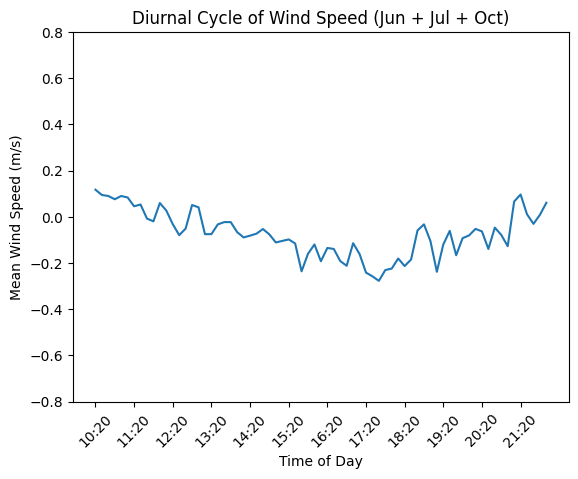

In [ ]:
mean_change_diurnal = df_selected.groupby("time")["wind_change_20min"].mean()
mean_change_diurnal = mean_change_diurnal.sort_index()

# Diurnal Cycle of Wind Speed plot
import matplotlib.pyplot as plt
plt.plot(mean_change_diurnal.index[2:], mean_change_diurnal.values[2:])
#plt.xticks(rotation=45)
plt.xticks(mean_change_diurnal.index[2::6], rotation=45)
plt.ylim(-0.8, 0.8)
plt.xlabel("Time of Day")
plt.ylabel("Mean Wind Speed (m/s)")
plt.title("Diurnal Cycle of Wind Speed (Jun + Jul + Oct)")
plt.show()

/tmp/ipykernel_1187/3224175089.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(df_selected["Wind speed (m/s)"].mean())
/tmp/ipykernel_1187/3224175089.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(df_selected["Wind speed (m/s)"].mean())
/tmp/ipykernel_1187/3224175089.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

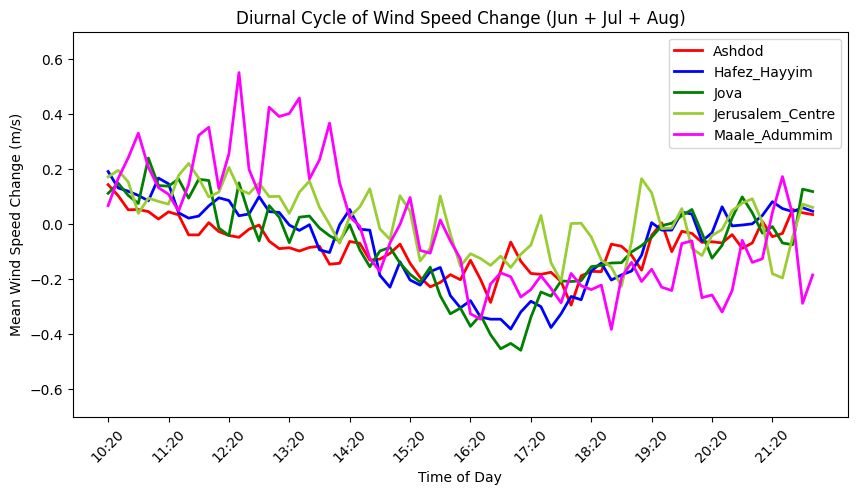

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process stations

def compute_diurnal(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    df1 = df[["Date & Time (UTC)", "Wind speed (m/s)"]].copy()
    df1.columns = df1.columns.str.strip()

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Filter months and time
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Wind change (20 min)
    df_selected["wind_change_20min"] = (
        df_selected["Wind speed (m/s)"] -
        df_selected["Wind speed (m/s)"].shift(2)
    ).fillna(df_selected["Wind speed (m/s)"].mean())

    # Compute mean diurnal cycle
    mean_diurnal = df_selected.groupby("time")["wind_change_20min"].mean()
    mean_diurnal = mean_diurnal.sort_index()

    return mean_diurnal

# File paths for stations
# ===============================
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Compute diurnal cycles
# ===============================
mean_diurnal1 = compute_diurnal(file_path1)
mean_diurnal2 = compute_diurnal(file_path2)
mean_diurnal3 = compute_diurnal(file_path3)
mean_diurnal4 = compute_diurnal(file_path4)
mean_diurnal5 = compute_diurnal(file_path5)

# Plot all in one graph
plt.figure(figsize=(10,5))

plt.plot(mean_diurnal1.index[2:], mean_diurnal1.values[2:], linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(mean_diurnal2.index[2:], mean_diurnal2.values[2:], linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(mean_diurnal3.index[2:], mean_diurnal3.values[2:], linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(mean_diurnal4.index[2:], mean_diurnal4.values[2:], linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(mean_diurnal5.index[2:], mean_diurnal5.values[2:], linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")


plt.xticks(mean_diurnal1.index[2::6], rotation=45)
plt.ylim(-0.7, 0.7)

plt.xlabel("Time of Day")
plt.ylabel("Mean Wind Speed Change (m/s)")
plt.title("Diurnal Cycle of Wind Speed Change (Jun + Jul + Aug)")

plt.legend()
#plt.grid(True)

plt.savefig("Mean_wind_change.png", dpi=300, bbox_inches='tight')
plt.show()

# **Mean Wind Speed Change for 10th July**

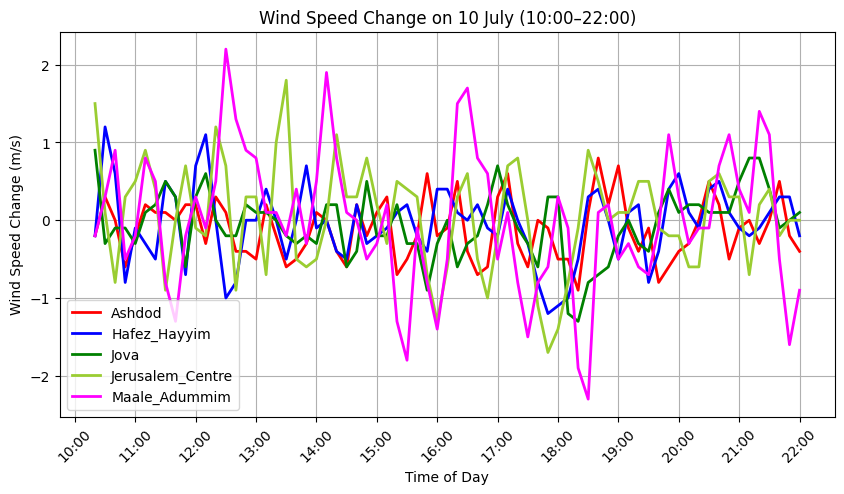

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_wind_change_single_day(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    df1 = df[["Date & Time (UTC)", "Wind speed (m/s)"]].copy()
    df1.columns = df1.columns.str.strip()

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # 10 July
    df_selected = df1[
        (df1.index.month == 7) &
        (df1.index.day == 10)
    ].between_time("10:00", "22:00")

    # Wind change (20 min → shift)
    df_selected["wind_change_20min"] = (
        df_selected["Wind speed (m/s)"] -
        df_selected["Wind speed (m/s)"].shift(2)
    )
    # drop NaN if exist
    #df_selected = df_selected.dropna()

    return df_selected



# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Format x-axis to show only time (HH:MM)
time_labels = df1.index.strftime("%H:%M")

# Compute for each station
df1 = compute_wind_change_single_day(file_path1)
df2 = compute_wind_change_single_day(file_path2)
df3 = compute_wind_change_single_day(file_path3)
df4 = compute_wind_change_single_day(file_path4)
df5 = compute_wind_change_single_day(file_path5)

plt.figure(figsize=(10,5))

plt.plot(df1.index, df1["wind_change_20min"], linewidth=2, color='red', label="Ashdod")
plt.plot(df2.index, df2["wind_change_20min"], linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(df3.index, df3["wind_change_20min"], linewidth=2, color='green', label="Jova")
plt.plot(df4.index, df4["wind_change_20min"], linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(df5.index, df5["wind_change_20min"], linewidth=2, color='magenta', label="Maale_Adummim")

plt.xticks(df1.index[::6], time_labels[::6], rotation=45)

#plt.ylim(-0.7, 0.7)

plt.xlabel("Time of Day")
plt.ylabel("Wind Speed Change (m/s)")
plt.title("Wind Speed Change on 10 July (10:00–22:00)")

plt.legend()
plt.grid(True)

plt.savefig("Wind_change_10_July.png", dpi=300, bbox_inches='tight')
plt.show()

# **Mean Daily Temperature Plots during Summar**

/tmp/ipykernel_4405/4067200878.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
/tmp/ipykernel_4405/4067200878.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
/tmp/ipykernel_4405/4067200878.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

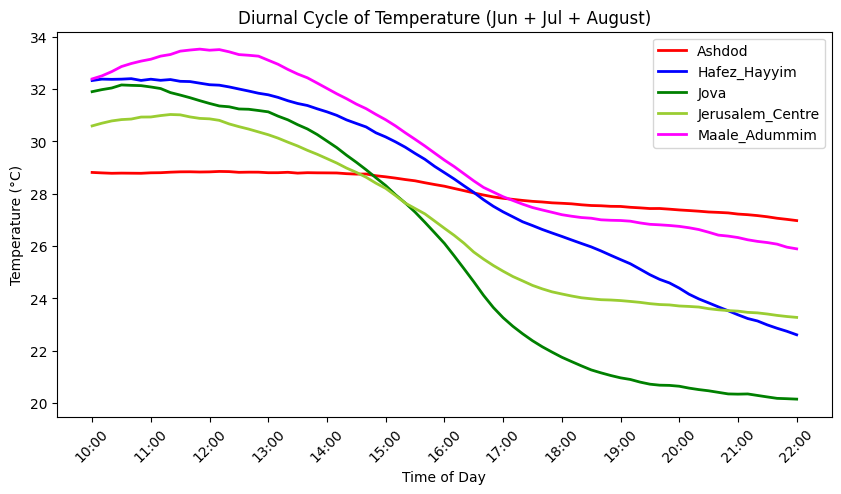

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
# ===============================
def compute_diurnal(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    df1 = df[["Date & Time (UTC)", "Temperature (°C)"]]
    df1.columns = df1.columns.str.strip()

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Filter months and time
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Compute mean diurnal cycle
    mean_diurnal = df_selected.groupby("time")["Temperature (°C)"].mean()
    mean_diurnal = mean_diurnal.sort_index()

    return mean_diurnal

# File paths for two stations
file_path1 = "/content/Ashdod_data.xlsx"
#file_path2 = "/content/Jerusalem_Givat_Ram_data.xlsx"   # <-- change this
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Compute diurnal cycles
# ===============================
mean_diurnal1 = compute_diurnal(file_path1)
mean_diurnal2 = compute_diurnal(file_path2)
mean_diurnal3 = compute_diurnal(file_path3)
mean_diurnal4 = compute_diurnal(file_path4)
mean_diurnal5 = compute_diurnal(file_path5)

# Plot both in one graph
plt.figure(figsize=(10,5))

plt.plot(mean_diurnal1.index, mean_diurnal1.values, marker='None', linestyle='-', color='red', linewidth=2, label="Ashdod")
plt.plot(mean_diurnal2.index, mean_diurnal2.values, marker='None', linestyle='-', color='blue', linewidth=2, label="Hafez_Hayyim")
plt.plot(mean_diurnal3.index, mean_diurnal3.values, marker='None', linestyle='-', color='green', linewidth=2, label="Jova")
plt.plot(mean_diurnal4.index, mean_diurnal4.values, marker='None', linestyle='-', color='yellowgreen', linewidth=2, label="Jerusalem_Centre")
plt.plot(mean_diurnal5.index, mean_diurnal5.values, marker='None', linestyle='-', color='magenta', linewidth=2, label="Maale_Adummim")

plt.xticks(mean_diurnal1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Temperature (°C)")
plt.title("Diurnal Cycle of Temperature (Jun + Jul + August)")

plt.legend()
#plt.grid(True)
plt.savefig("Mean_Temperature.png", dpi=300, bbox_inches='tight')
plt.show()

# **One Day Temperature 10th July**

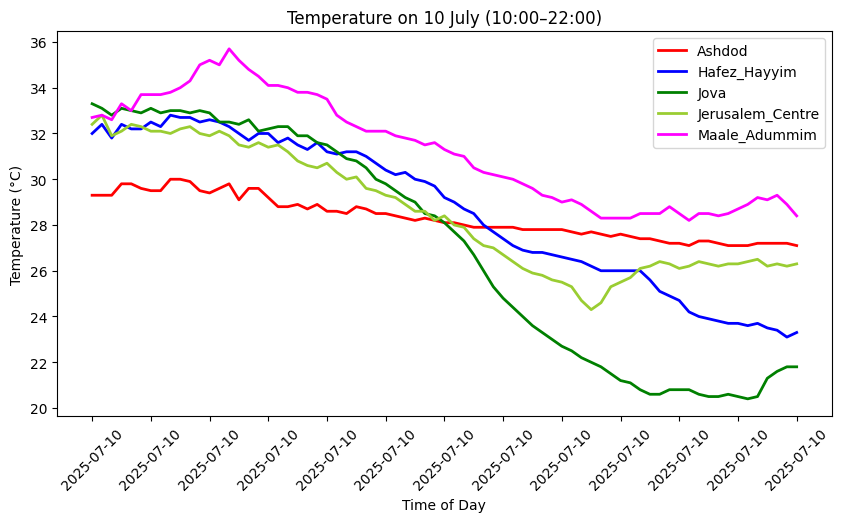

In [ ]:
# Temperature on 10 July (Single Day Analysis)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# Function: Extract 10 July data
# ==========================================
def compute_temp_single_day(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns
    df1 = df[["Date & Time (UTC)", "Temperature (°C)"]].copy()
    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
    df1 = df1.dropna(subset=["Temperature (°C)"])

    # Convert datetime
    df1["Date & Time (UTC)"] = pd.to_datetime(df1["Date & Time (UTC)"], dayfirst=True)
    df1.set_index("Date & Time (UTC)", inplace=True)

    # Sort index
    df1 = df1.sort_index()

    # Filter ONLY 10 July (10:00–22:00)
    df_selected = df1[
        (df1.index.month == 7) &
        (df1.index.day == 10)
    ].between_time("10:00", "22:00")

    return df_selected

# File paths
# ==========================================
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


df1 = compute_temp_single_day(file_path1)
df2 = compute_temp_single_day(file_path2)
df3 = compute_temp_single_day(file_path3)
df4 = compute_temp_single_day(file_path4)
df5 = compute_temp_single_day(file_path5)

# Format x-axis to show only time (HH:MM)
time_labels = df1.index.strftime("%H:%M")

plt.figure(figsize=(10,5))

plt.plot(df1.index, df1["Temperature (°C)"], color='red', linewidth=2, label="Ashdod")
plt.plot(df2.index, df2["Temperature (°C)"], color='blue', linewidth=2, label="Hafez_Hayyim")
plt.plot(df3.index, df3["Temperature (°C)"], color='green', linewidth=2, label="Jova")
plt.plot(df4.index, df4["Temperature (°C)"], color='yellowgreen', linewidth=2, label="Jerusalem_Centre")
plt.plot(df5.index, df5["Temperature (°C)"], color='magenta', linewidth=2, label="Maale_Adummim")
plt.xticks(df1.index[::6], rotation=45)

# Labels and title
plt.xlabel("Time of Day")
plt.ylabel("Temperature (°C)")
plt.title("Temperature on 10 July (10:00–22:00)")

plt.legend()

# Save and show
plt.savefig("Temperature_10_July.png", dpi=300, bbox_inches='tight')
plt.show()

# **Hourly rate of Change of Temperature**

/tmp/ipykernel_564/2205604280.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
/tmp/ipykernel_564/2205604280.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
/tmp/ipykernel_564/2205604280.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

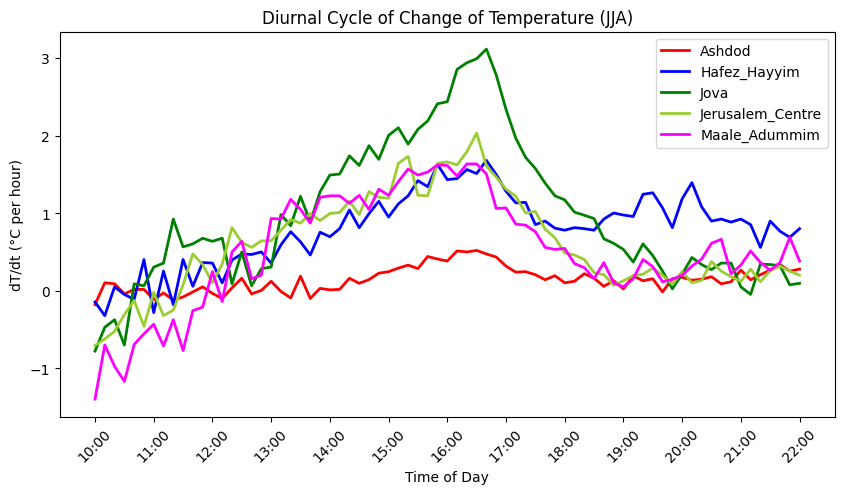

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_diurnal_temp_rate(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns
    df1 = df[["Date & Time (UTC)", "Temperature (°C)"]]
    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna(subset=["Temperature (°C)"])

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Sort index (VERY IMPORTANT)
    df1 = df1.sort_index()

    # ==========================
    # BACKWARD DIFFERENCE (10 min → hourly rate)
    # ==========================
    df1["dT_dt"] = (-df1["Temperature (°C)"] + df1["Temperature (°C)"].shift(1)) * 6

    # Remove NaN from first shift
    df1 = df1.dropna(subset=["dT_dt"])

    # ==========================
    # Filter JJA + daytime
    # ==========================
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Mean diurnal of rate
    mean_diurnal_rate = df_selected.groupby("time")["dT_dt"].mean()
    mean_diurnal_rate = mean_diurnal_rate.sort_index()

    return mean_diurnal_rate


# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Compute diurnal temperature rate
rate1 = compute_diurnal_temp_rate(file_path1)
rate2 = compute_diurnal_temp_rate(file_path2)
rate3 = compute_diurnal_temp_rate(file_path3)
rate4 = compute_diurnal_temp_rate(file_path4)
rate5 = compute_diurnal_temp_rate(file_path5)

# ==========================
# Plot
# ==========================
plt.figure(figsize=(10,5))
plt.plot(rate1.index, rate1.values, marker='None', linestyle='-', color='red', linewidth=2, label="Ashdod")
plt.plot(rate2.index, rate2.values, marker='None', linestyle='-', color='blue', linewidth=2, label="Hafez_Hayyim")
plt.plot(rate3.index, rate3.values, marker='None', linestyle='-', color='green', linewidth=2, label="Jova")
plt.plot(rate4.index, rate4.values, marker='None', linestyle='-', color='yellowgreen', linewidth=2, label="Jerusalem_Centre")
plt.plot(rate5.index, rate5.values, marker='None', linestyle='-', color='magenta', linewidth=2, label="Maale_Adummim")


plt.xticks(rate1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("dT/dt (°C per hour)")
plt.title("Diurnal Cycle of Change of Temperature (JJA)")

plt.legend()
plt.savefig("dT_dt_diurnal.png", dpi=300, bbox_inches='tight')
plt.show()

# **Rate of change of Temperature for 10th July**

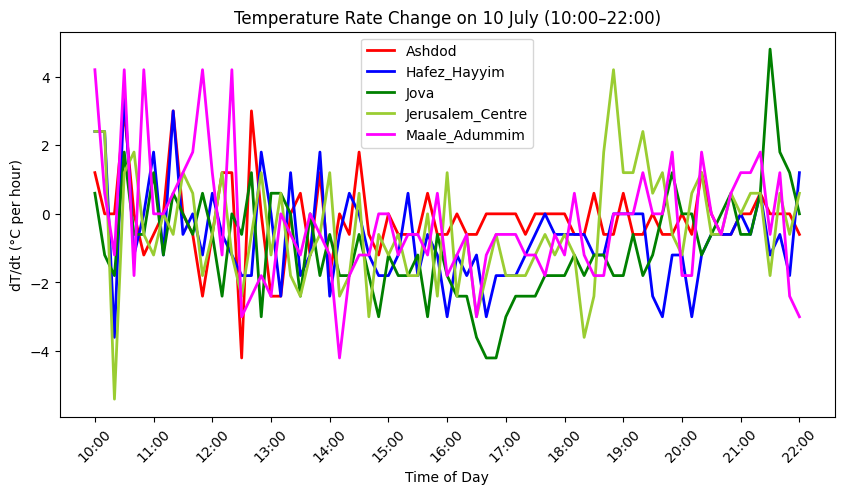

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_temp_rate_single_day(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns
    df1 = df[["Date & Time (UTC)", "Temperature (°C)"]].copy()
    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna(subset=["Temperature (°C)"])

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Sort index
    df1 = df1.sort_index()

    # BACKWARD DIFFERENCE (10 min → hourly rate)
    df1["dT_dt"] = (
        df1["Temperature (°C)"] - df1["Temperature (°C)"].shift(1)
    ) * 6   # correct sign (present - previous)

    df1 = df1.dropna(subset=["dT_dt"])

    # ✅ Filter ONLY 10 July
    df_selected = df1[
        (df1.index.month == 7) &
        (df1.index.day == 10)
    ].between_time("10:00", "22:00")

    return df_selected

# Format x-axis to show only time (HH:MM)
time_labels = df1.index.strftime("%H:%M")
#import matplotlib.dates as mdates

# Compute for each station
df1 = compute_temp_rate_single_day(file_path1)
df2 = compute_temp_rate_single_day(file_path2)
df3 = compute_temp_rate_single_day(file_path3)
df4 = compute_temp_rate_single_day(file_path4)
df5 = compute_temp_rate_single_day(file_path5)

plt.figure(figsize=(10,5))

plt.plot(df1.index, df1["dT_dt"], linestyle='-', color='red', linewidth=2, label="Ashdod")
plt.plot(df2.index, df2["dT_dt"], linestyle='-', color='blue', linewidth=2, label="Hafez_Hayyim")
plt.plot(df3.index, df3["dT_dt"], linestyle='-', color='green', linewidth=2, label="Jova")
plt.plot(df4.index, df4["dT_dt"], linestyle='-', color='yellowgreen', linewidth=2, label="Jerusalem_Centre")
plt.plot(df5.index, df5["dT_dt"], linestyle='-', color='magenta', linewidth=2, label="Maale_Adummim")

#plt.xticks(df1.index[::6], time_labels[::6], rotation=45)
plt.xticks(df1.index[::6], time_labels[::6], rotation=45)

plt.xlabel("Time of Day")
plt.ylabel("dT/dt (°C per hour)")
plt.title("Temperature Rate Change on 10 July (10:00–22:00)")

plt.legend()
plt.savefig("dT_dt_10_July.png", dpi=300, bbox_inches='tight')
plt.show()

# **Gustiness or Turbulence intensity Evaluation**

/tmp/ipykernel_4799/2750518533.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Date & Time (UTC)'] = pd.to_datetime(df2['Date & Time (UTC)'], dayfirst=True)


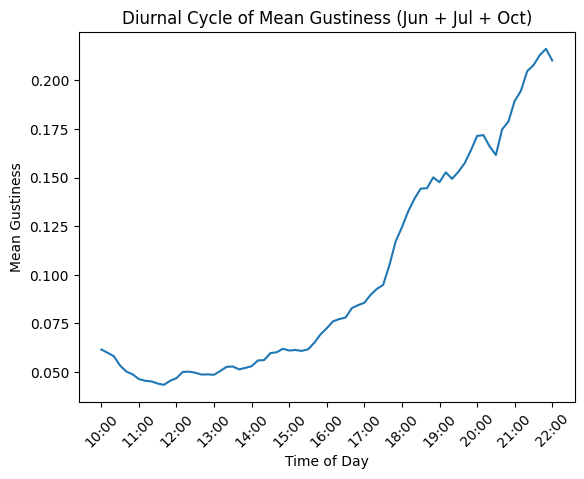

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# 1. Load Data
file_path1 = "/content/Ashdod_data.xlsx"  # change path if needed

df = pd.read_excel(file_path1, engine="openpyxl")
df["v"] = df["Wind speed (m/s)"]

df["v"] = pd.to_numeric(df["v"], errors="coerce")
df["v_mean_50min"] = df["v"].rolling(window=6).mean()
df["v_std_50min"] = df["v"].rolling(window=6).std()

df["gustiness"] = df["v_std_50min"] / df["v_mean_50min"]

df2=df[["Date & Time (UTC)","gustiness"]]

# Clean column names
df2.columns = df2.columns.str.strip()
# Convert datetime
df2['Date & Time (UTC)'] = pd.to_datetime(df2['Date & Time (UTC)'], dayfirst=True)

# Set index
df2.set_index('Date & Time (UTC)', inplace=True)
# Slice the dataset
df_sel = df2[df2.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

# Time Index
df_sel["time"] = df_sel.index.time
df_sel["time"] = df_sel.index.strftime("%H:%M")


mean_gust = df_sel.groupby("time")["gustiness"].mean()
mean_gust = mean_gust.sort_index()

mean_gust = df_sel.groupby("time")["gustiness"].mean()
mean_gust = mean_gust.sort_index()

# Diurnal Cycle of Wind Speed plot
import matplotlib.pyplot as plt
plt.plot(mean_gust.index, mean_gust.values)
#plt.xticks(rotation=45)
plt.xticks(mean_gust.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Gustiness")
plt.title("Diurnal Cycle of Mean Gustiness (Jun + Jul + Oct)")
plt.show()

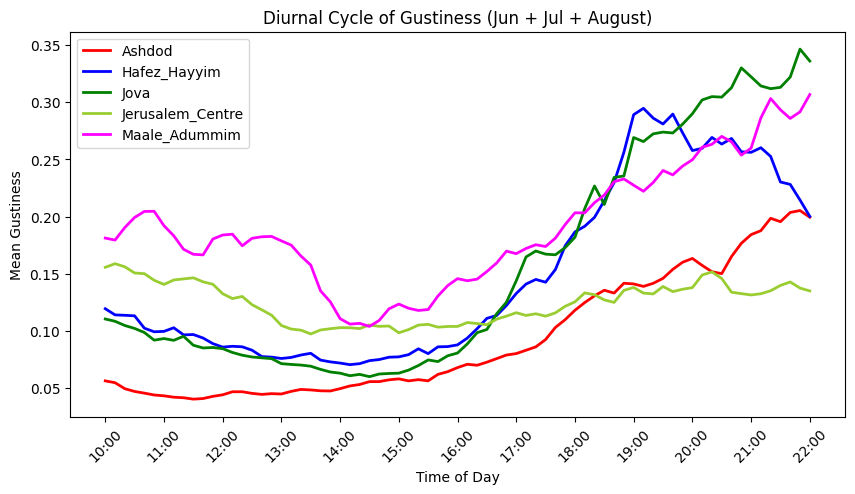

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_gustiness(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Wind speed
    df["v"] = pd.to_numeric(df["Wind speed (m/s)"], errors="coerce")
    # Rolling stats(50 min=5 points)
    df["v_mean_50min"] = df["v"].rolling(window=5).mean()
    df["v_std_50min"] = df["v"].rolling(window=5).std()

    # Gustiness
    df["gustiness"] = df["v_std_50min"] / (df["v_mean_50min"] + 1e-6) # avoid the Inf
    # Keep required columns
    df1 = df[["Date & Time (UTC)", "gustiness"]].copy()

    df1.columns = df1.columns.str.strip()
    # Convert datetime
    df1["Date & Time (UTC)"] = pd.to_datetime(df1["Date & Time (UTC)"], dayfirst=True)
    df1.set_index("Date & Time (UTC)", inplace=True)

    # Filter months + time
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")
    # Time index
    df_selected["time"] = df_selected.index.strftime("%H:%M")
    # Diurnal mean
    mean_gust = df_selected.groupby("time")["gustiness"].mean().sort_index()

    return mean_gust


# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Station names
stations = ["Ashdod", "Hafez_Hayyim", "Jova", "Jerusalem_Centre", "Maale_Adummim"]

# Compute diurnal cycles
mean1 = compute_gustiness(file_path1)
mean2 = compute_gustiness(file_path2)
mean3 = compute_gustiness(file_path3)
mean4 = compute_gustiness(file_path4)
mean5 = compute_gustiness(file_path5)


plt.figure(figsize=(10,5))
plt.plot(mean1.index, mean1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(mean2.index, mean2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(mean3.index, mean3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(mean4.index, mean4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(mean5.index, mean5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")

plt.xticks(mean1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Gustiness")
plt.title("Diurnal Cycle of Gustiness (Jun + Jul + August)")

plt.legend()
# plt.grid(True)

plt.savefig("Mean_Gustiness.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#print(df_sel["gustiness"])
#mean_gust = df_sel["gustiness"].sort_index()



In [ ]:
#print(mean_gust)

# **Direct plot of Gust wind Speed**

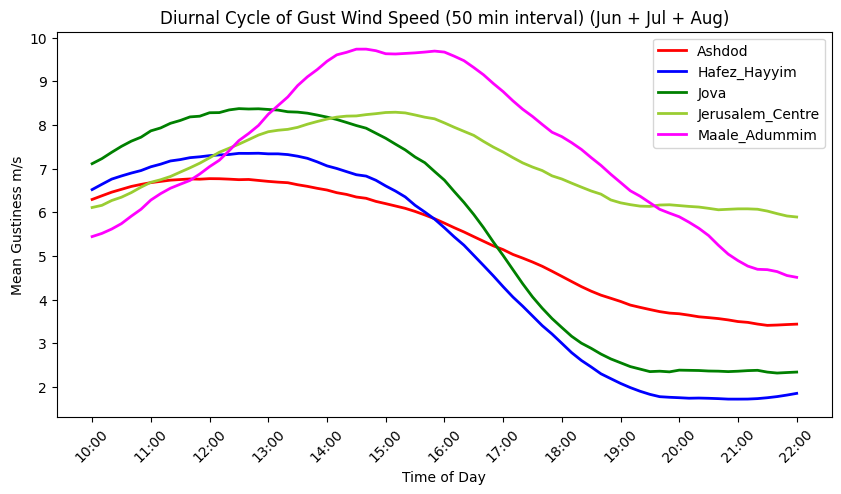

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_gustiness(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Wind speed
    df["v"] = pd.to_numeric(df["Gust wind speed (m/s)"], errors="coerce")
    # Rolling stats(50 min=5 points)
    df["gustiness"] = df["v"].rolling(window=5).mean()
    #df["v_std_50min"] = df["v"].rolling(window=5).std()

    # Gustiness
    #df["gustiness"] = df["v_std_50min"] / (df["v_mean_50min"] + 1e-6) # avoid the Inf
    # Keep required columns
    df1 = df[["Date & Time (UTC)", "gustiness"]].copy()

    df1.columns = df1.columns.str.strip()
    # Convert datetime
    df1["Date & Time (UTC)"] = pd.to_datetime(df1["Date & Time (UTC)"], dayfirst=True)
    df1.set_index("Date & Time (UTC)", inplace=True)

    # Filter months + time
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")
    # Time index
    df_selected["time"] = df_selected.index.strftime("%H:%M")
    # Diurnal mean
    mean_gust = df_selected.groupby("time")["gustiness"].mean().sort_index()

    return mean_gust


# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Station names
stations = ["Ashdod", "Hafez_Hayyim", "Jova", "Jerusalem_Centre", "Maale_Adummim"]

# Compute diurnal cycles
mean1 = compute_gustiness(file_path1)
mean2 = compute_gustiness(file_path2)
mean3 = compute_gustiness(file_path3)
mean4 = compute_gustiness(file_path4)
mean5 = compute_gustiness(file_path5)


plt.figure(figsize=(10,5))
plt.plot(mean1.index, mean1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(mean2.index, mean2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(mean3.index, mean3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(mean4.index, mean4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(mean5.index, mean5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")

plt.xticks(mean1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Gustiness m/s")
plt.title("Diurnal Cycle of Gust Wind Speed (50 min interval) (Jun + Jul + Aug)")

plt.legend()
# plt.grid(True)

plt.savefig("Mean_Gustiness.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(df["gustiness"].head(8))

0         NaN
1         NaN
2         NaN
3         NaN
4    0.072955
5    0.070973
6    0.070803
7    0.066261
Name: gustiness, dtype: float64


In [ ]:
print("What is meant by turbulence intensity or Gustiness?")

What is meant by turbulence intensity or Gustiness?


In [ ]:
df_selected["wind_change_20min"][2]

/tmp/ipykernel_6335/2303561405.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_selected["wind_change_20min"][2]


np.float64(0.10000000000000053)

In [ ]:
df_selected

,Wind speed (m/s),time,wind_change_20min
Date & Time (UTC),,,
2025-06-01 10:00:00,5.8,10:00,NaN
2025-06-01 10:10:00,5.5,10:10,NaN
2025-06-01 10:20:00,5.9,10:20,0.1
2025-06-01 10:30:00,5.9,10:30,0.4
2025-06-01 10:40:00,6.2,10:40,0.3
...,...,...,...
2025-10-31 21:20:00,3.7,21:20,1.0
2025-10-31 21:30:00,3.8,21:30,0.7
2025-10-31 21:40:00,3.7,21:40,0.0


# **Code for different station plots of Mean Wind Speed **

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. File paths for stations
# ===============================
files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    #"Nahshon": "/content/Nahshon_data.xlsx",
    "Jova": "/content/Jova_data.xlsx",
    "Jerusalem_Givat_Ram": "/content/Jerusalem_Givat_Ram_data.xlsx",
    #"Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}

import pandas as pd
import matplotlib.pyplot as plt

#mean_wind = {}

dfs = []

for name, path1 in files.items():

    # Ensure datetime index
    df_full = pd.read_excel(path1)

    df_full.columns = df_full.columns.str.strip()

    #df_full.index = pd.to_datetime(df_full.index)
    #print(name, "loaded:", df_full.head())

    # Convert datetime
    df_full['Date & Time (UTC)'] = pd.to_datetime(df_full['Date & Time (UTC)'], dayfirst=True)

    # Set index
    df_full.set_index('Date & Time (UTC)', inplace=True)
    # Filter months
    df_sel = df_full[df_full.index.month.isin([6, 7, 10])].between_time("10:00", "22:00")

    #df_sel["time"] = df_selected.index.time
    #df_sel["time"] = df_selected.index.strftime("%H:%M")
    #mean_diurnal = df_sel.groupby("time")["Wind speed (m/s)"].mean()

    #mean_diurnal = mean_diurnal.sort_index()
    dfs.append(df_sel)


    #mean_diurnal = mean_diurnal.sort_index()

    # # Mean wind speed for station
    # mean_wind[name] = df_sel["Wind speed (m/s)"].mean()

# Merge all dataframes on time index
merged_df = pd.concat(dfs, axis=1)

In [ ]:
merged_df.shape

(6716, 77)

In [ ]:
#df_clean = merged_df.reset_index()[["Date & Time (UTC)", "Station", "Wind speed (m/s)"]]
df_clean = merged_df.reset_index()[["Date & Time (UTC)", "Wind speed (m/s)"]]

df_clean["Date & Time (UTC)"] = pd.to_datetime(df_clean["Date & Time (UTC)"])
df_clean["date"] = df_clean["Date & Time (UTC)"].dt.date

In [ ]:
wind_cols = df_clean.filter(like="Wind speed")
wind_cols = wind_cols.apply(pd.to_numeric, errors="coerce")


# Interpolate missing values
wind_cols = wind_cols.interpolate()

# Put back into dataframe
#df_clean[wind_cols.columns] = wind_cols

df_clean["mean_ws"] = wind_cols.mean(axis=1)
#
daily_mean = df_clean.groupby("date")["mean_ws"].mean()

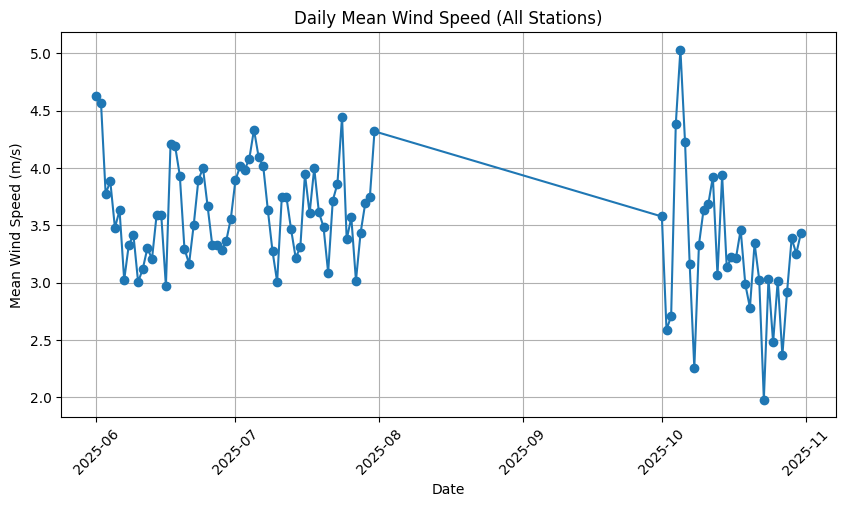

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(daily_mean.index, daily_mean.values, marker='o')

plt.xlabel("Date")
plt.ylabel("Mean Wind Speed (m/s)")
plt.title("Daily Mean Wind Speed (All Stations)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
df_clean.shape
#print(df_clean.shape)

(6716, 8)

In [ ]:
#print()
df_clean.head()

,Date & Time (UTC),Wind speed (m/s),Wind speed (m/s),Wind speed (m/s),Wind speed (m/s),Wind speed (m/s),date
0,2025-06-01 10:00:00,5.8,4.6,4.1,2.9,2.2,2025-06-01
1,2025-06-01 10:10:00,5.5,4.8,4.4,2.6,1.4,2025-06-01
2,2025-06-01 10:20:00,5.9,4.8,4.1,2.3,1.9,2025-06-01
3,2025-06-01 10:30:00,5.9,5.4,4.2,5.4,2,2025-06-01
4,2025-06-01 10:40:00,6.2,5.4,3.1,3.2,1.1,2025-06-01


In [ ]:
# import matplotlib.pyplot as plt
# plt.plot(df_clean.index, df_clean["Wind speed (m/s)"])
# plt.show()

In [ ]:
# df_clean["Date & Time (UTC)"] = pd.to_datetime(df_clean["Date & Time (UTC)"])

# df_clean = df_clean.set_index("Date & Time (UTC)")

# # Extract time properly
# df_clean["time"] = df_clean.index.strftime("%H:%M")
#df_clean = df_selected.groupby("time")["Wind speed (m/s)"].mean()

#df_clean = mean_diurnal.sort_index()

KeyError: 'Date & Time (UTC)'

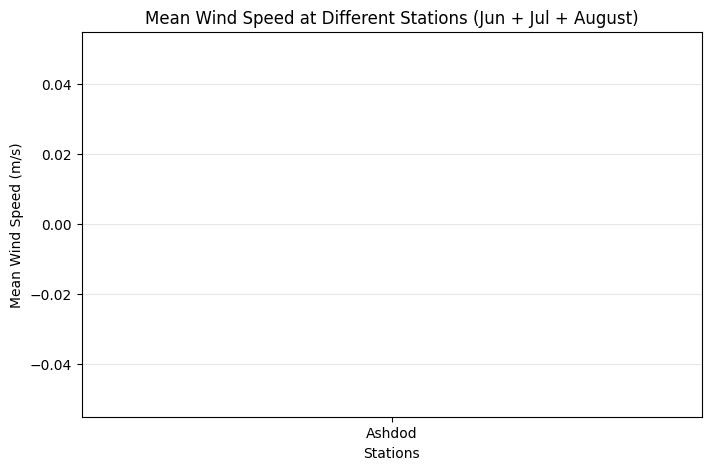

In [ ]:
mean_series = pd.Series(mean_wind)
plt.figure(figsize=(8,5))

plt.bar(mean_series.index, mean_series.values)

plt.xlabel("Stations")
plt.ylabel("Mean Wind Speed (m/s)")
plt.title("Mean Wind Speed at Different Stations (Jun + Jul + August)")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
print(df_selected.head())

                    Wind speed (m/s)
Date & Time (UTC)                   
2025-06-01 10:00:00              5.8
2025-06-01 10:10:00              5.5
2025-06-01 10:20:00              5.9
2025-06-01 10:30:00              5.9
2025-06-01 10:40:00              6.2


In [ ]:
df1["month"] = df1["Date & Time (UTC)"].dt.month

KeyError: 'Date & Time (UTC)'

In [ ]:
print(df1.head())

                    Wind speed (m/s)
Date & Time (UTC)                   
2025-04-03 00:00:00              5.3
2025-04-03 00:10:00              5.3
2025-04-03 00:20:00              5.1
2025-04-03 00:30:00              4.7
2025-04-03 00:40:00              4.5


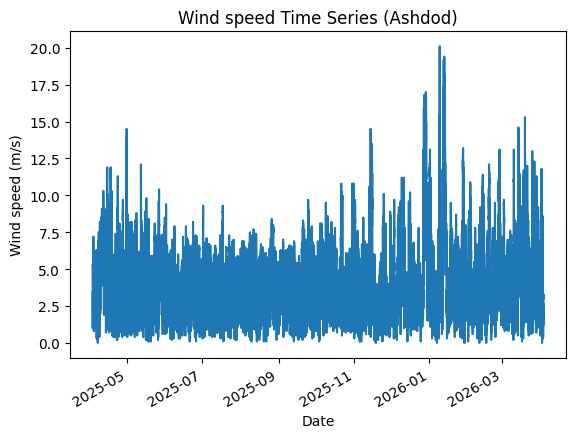

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Clean column names
df_one.columns = df_one.columns.str.strip()

# Convert datetime
df_one['Date & Time (UTC)'] = pd.to_datetime(df_one['Date & Time (UTC)'], dayfirst=True)

# Set index
df_one.set_index('Date & Time (UTC)', inplace=True)

# Clean temperature column
df_one['Wind speed (m/s)'] = pd.to_numeric(df_one['Wind speed (m/s)'], errors='coerce')
df_one['Wind speed (m/s)'] = df_one['Wind speed (m/s)'].interpolate()

# Plot
plt.figure()
df_one['Wind speed (m/s)'].plot()

plt.title("Wind speed Time Series (Ashdod)")
plt.xlabel("Date")
plt.ylabel("Wind speed (m/s)")

plt.show()

# **Here I have load all 8 station dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. File paths for stations
# ===============================
files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Quvuzat": "/content/Quvuzat_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Nahshon": "/content/Nahshon_data.xlsx",
    "Jova": "/content/Jova_data.xlsx",
    "Jerusalem_Givat_Ram": "/content/Jerusalem_Givat_Ram_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


In [ ]:
df_list = []

# 2. Load & preprocess each station
# ===============================
for station_name, file_path in files.items():

    df = pd.read_excel(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Convert datetime
    df['Date & Time (UTC)'] = pd.to_datetime(df['Date & Time (UTC)'], dayfirst=True)

    # Set index
    df.set_index('Date & Time (UTC)', inplace=True)

    # Clean temperature
    df['Temperature (°C)'] = pd.to_numeric(df['Temperature (°C)'], errors='coerce')
    df['Temperature (°C)'] = df['Temperature (°C)'].interpolate()

    # Keep only temperature & rename column
    df = df[['Temperature (°C)']]
    df.rename(columns={'Temperature (°C)': station_name}, inplace=True)

    df_list.append(df)

# 3. Merge all stations
# ===============================
data = pd.concat(df_list, axis=1)

# Optional: interpolate missing values after merge
data = data.interpolate(method='time')

print(data.head())


                     Ashdod  Quvuzat  Hafez_Hayyim  Nahshon  Jova  \
Date & Time (UTC)                                                   
2025-04-03 00:00:00    16.1     13.0          12.7     12.6  11.0   
2025-04-03 00:10:00    15.8     13.0          12.7     12.7  10.7   
2025-04-03 00:20:00    15.8     13.1          12.6     12.7  10.3   
2025-04-03 00:30:00    15.8     13.0          12.6     12.7  10.6   
2025-04-03 00:40:00    15.8     12.9          12.4     12.6  10.7   

                     Jerusalem_Givat_Ram  Jerusalem_Centre  Maale_Adummim  
Date & Time (UTC)                                                          
2025-04-03 00:00:00                 13.0              13.9           15.0  
2025-04-03 00:10:00                 12.9              13.9           15.0  
2025-04-03 00:20:00                 12.9              14.0           15.2  
2025-04-03 00:30:00                 13.0              14.1           15.2  
2025-04-03 00:40:00                 13.1              14.3  

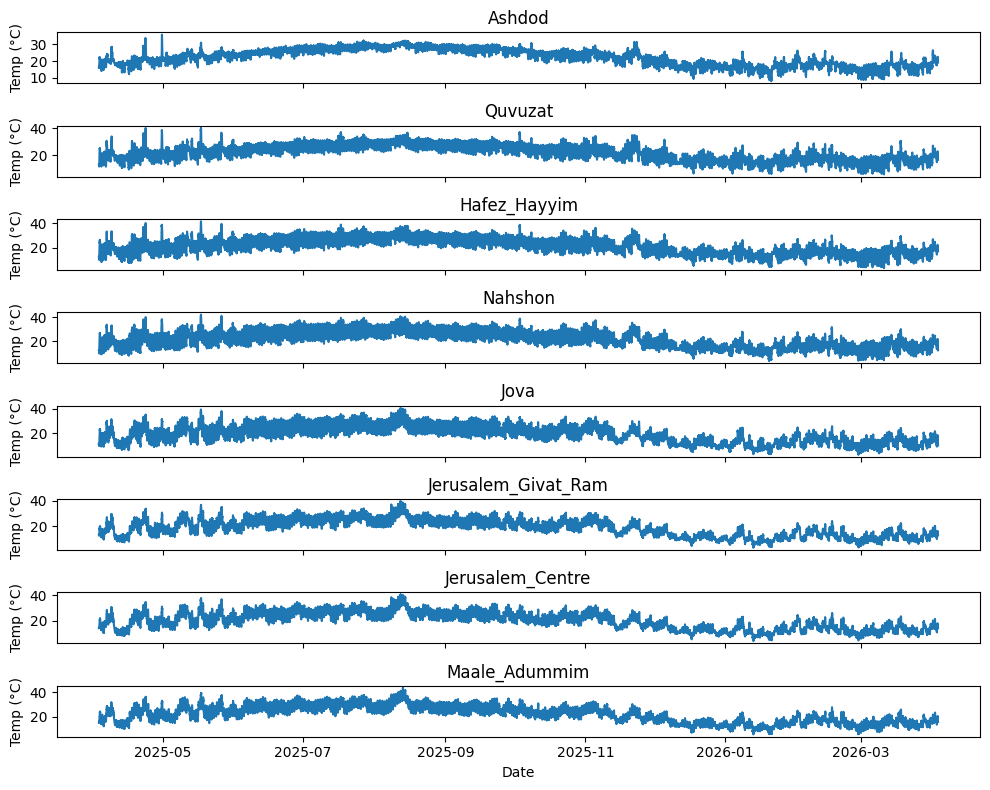

In [ ]:
import matplotlib.pyplot as plt

# Creating 8 plots for different stations
fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(10, 8), sharex=True)

# Loop through columns and plot in each subplot
for i, col in enumerate(data.columns[:8]):  # take first 3 stations
    axes[i].plot(data.index, data[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Temp (°C)")

# Common X label
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("weather_plot.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
df_list = []

# 2. Load & preprocess each station
# ===============================
for station_name, file_path in files.items():

    df = pd.read_excel(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Convert datetime
    df['Date & Time (UTC)'] = pd.to_datetime(df['Date & Time (UTC)'], dayfirst=True)

    # Set index
    df.set_index('Date & Time (UTC)', inplace=True)

    # Clean temperature
    df['Wind speed (m/s)'] = pd.to_numeric(df['Wind speed (m/s)'], errors='coerce')
    df['Wind speed (m/s)'] = df['Wind speed (m/s)'].interpolate()

    # Keep only temperature & rename column
    df = df[['Wind speed (m/s)']]
    df.rename(columns={'Wind speed (m/s)': station_name}, inplace=True)

    df_list.append(df)

# 3. Merge all stations
# ===============================
data = pd.concat(df_list, axis=1)

# Optional: interpolate missing values after merge
data = data.interpolate(method='time')

print(data.head())

KeyError: 'Wind speed (m/s)'

In [ ]:
df_list1 = []

for station_name, file_path in files.items():

    df = pd.read_excel(file_path)
print(df.isnull().sum)

# df.columns = (
#     df.columns
#     .str.strip()
#     .str.lower()
#     .str.replace(' ', '_')
# )

# print(df.columns.tolist())

#     # Clean column names
#     df.columns = df.columns.str.strip()

#     # Convert datetime
#     df['Date & Time (UTC)'] = pd.to_datetime(df['Date & Time (UTC)'], dayfirst=True)

#     # Set index
#     df.set_index('Date & Time (UTC)', inplace=True)

#     # Convert wind direction to numeric
#     df['Wind direction (°)'] = pd.to_numeric(df['Wind direction (°)'], errors='coerce')

#     # Interpolate
#     df['Wind direction (°)'] = df['Wind direction (°)'].interpolate()

#     # Keep only this column
#     df = df[['Wind direction (°)']]

#     # Rename column as station
#     df.rename(columns={'Wind direction (°)': station_name}, inplace=True)

#     df_list1.append(df)

# # Merge all stations
# data1 = pd.concat(df_list1, axis=1)

# # Interpolate AFTER merge (correct variable)
# data1 = data1.interpolate(method='time')

# print(data1.head())

<bound method DataFrame.sum of        Station  Date & Time (UTC)  Relative humidity (%)  Temperature (°C)  \
0        False              False                  False             False   
1        False              False                  False             False   
2        False              False                  False             False   
3        False              False                  False             False   
4        False              False                  False             False   
...        ...                ...                    ...               ...   
52073    False              False                  False             False   
52074    False              False                  False             False   
52075    False              False                  False             False   
52076    False              False                  False             False   
52077    False              False                  False             False   

       Maximum temperature (°C) 

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()
new_columns = [
    'station',
    'datetime_utc',
    'diffuse_radiation',
    'global_radiation',
    'direct_radiation',
    'relative_humidity',
    'temperature',
    'temp_max',
    'temp_min',
    'wet_temperature',
    'wind_direction',
    'gust_wind_direction',
    'wind_speed',
    'wind_speed_max_1min',
    'wind_speed_max_10min',
    'time_max_wind_10min',
    'gust_wind_speed',
    'wind_dir_std',
    'rainfall'
]

df.columns = new_columns
print(df.columns)

ValueError: Length mismatch: Expected axis has 16 elements, new values have 19 elements

In [ ]:
# # Convert to datetime first
# df['datetime_utc'] = pd.to_datetime(
#     df['datetime_utc'],
#     format='%d/%m/%Y %H:%M'
# )

# # Then apply timezone
# df['datetime_utc'] = (
#     df['datetime_utc']
#     .dt.tz_localize('UTC')
#     .dt.tz_convert('Asia/Jerusalem')   # for India
# )

df['datetime_utc'] = pd.to_datetime(df['datetime_utc'])

df['datetime_local'] = df['datetime_utc'].dt.tz_convert('Asia/Jerusalem')

In [ ]:
print(df['datetime_local'].head())

0   2025-03-23 02:00:00+02:00
1   2025-03-23 02:10:00+02:00
2   2025-03-23 02:20:00+02:00
3   2025-03-23 02:30:00+02:00
4   2025-03-23 02:40:00+02:00
Name: datetime_local, dtype: datetime64[ns, Asia/Jerusalem]


In [ ]:
df['Hour'] = df['datetime_local'].dt.hour
df['Minute'] = df['datetime_local'].dt.minute
df['DayOfYear'] = df['datetime_local'].dt.dayofyear

In [ ]:
df['Time_decimal'] = df['Hour'] + df['Minute'] / 60.0

df['Time_sin'] = np.sin(2 * np.pi * df['Time_decimal'] / 24)
df['Time_cos'] = np.cos(2 * np.pi * df['Time_decimal'] / 24)

df['Day_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['Day_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)

In [ ]:
df['wind_dir_rad'] = np.deg2rad(df['wind_direction'])

df['u'] = df['wind_speed'] * np.cos(df['wind_dir_rad'])
df['v'] = df['wind_speed'] * np.sin(df['wind_dir_rad'])

TypeError: can't multiply sequence by non-int of type 'float'

In [ ]:
print(df.head())

               station              datetime_utc diffuse_radiation  \
0  Jerusalem Givat Ram 2025-03-23 02:00:00+02:00                 0   
1  Jerusalem Givat Ram 2025-03-23 02:10:00+02:00                 0   
2  Jerusalem Givat Ram 2025-03-23 02:20:00+02:00                 0   
3  Jerusalem Givat Ram 2025-03-23 02:30:00+02:00                 0   
4  Jerusalem Givat Ram 2025-03-23 02:40:00+02:00                 0   

  global_radiation direct_radiation relative_humidity temperature temp_max  \
0                0                0                84         6.3      6.4   
1                0                0                85         6.3      6.3   
2                0                0                85         6.3      6.4   
3                0                0                85         6.3      6.4   
4                0                0                86         6.3      6.3   

  temp_min wet_temperature  ...  rainfall            datetime_local Hour  \
0      6.3               -  ...   

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Rename
df.rename(columns={'Date & Time (UTC)': 'DateTime'}, inplace=True)

# Now your original code works
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H:%M')

df = df.sort_values('DateTime')

df['Hour'] = df['DateTime'].dt.hour
df['DayOfYear'] = df['DateTime'].dt.dayofyear

df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

NameError: name 'df' is not defined

In [ ]:
# import pandas as pd

# # # Example column
# # df = pd.DataFrame({
# #     'DateTime': [
# #         '23/03/2025 00:00',
# #         '23/03/2025 00:10',
# #         '23/03/2025 00:20'
# #     ]
# # })

# df.rename(columns={'Date & Time (UTC)': 'DateTime'}, inplace=True)

# # Convert to datetime
# df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H:%M')

# # Extract only time
# df['Time'] = df['DateTime'].dt.time

# print(df.head(2))

In [ ]:
print(df.head(2))

               Station            DateTime Diffused radiation (W/m^2)  \
0  Jerusalem Givat Ram 2025-03-23 00:00:00                          0   
1  Jerusalem Givat Ram 2025-03-23 00:10:00                          0   

  Global radiation (W/m^2) Direct radiation (W/m^2) Relative humidity (%)  \
0                        0                        0                    84   
1                        0                        0                    85   

  Temperature (°C) Maximum temperature (°C) Minimum temperature (°C)  \
0              6.3                      6.4                      6.3   
1              6.3                      6.3                      6.2   

  Wet Temperature (°C)  ...  Maximum 1 minute wind speed (m/s)  \
0                    -  ...                                2.4   
1                    -  ...                                2.3   

   Maximum 10 minutes wind speed (m/s)  \
0                                  2.0   
1                                  1.9   

  Tim

In [ ]:
# ===============================
# 4. Handle Missing Values
# ===============================
# Forward fill (good for time series)
df = df.fillna(method='ffill')

# If still missing → backward fill
df = df.fillna(method='bfill')

# ===============================
# 5. Wind Transformation (VERY IMPORTANT)
# ===============================
# Convert degrees to radians
df['WindDir_rad'] = np.deg2rad(df['WindDirection'])

# Wind components
df['u'] = df['WindSpeed'] * np.cos(df['WindDir_rad'])
df['v'] = df['WindSpeed'] * np.sin(df['WindDir_rad'])

# ===============================
# 6. Optional: Rolling Features (captures sea-breeze evolution)
# ===============================
window = 6  # e.g., 1 hour if data is 10-min interval

df['Temp_roll_mean'] = df['Temperature'].rolling(window).mean()
df['Wind_roll_mean'] = df['WindSpeed'].rolling(window).mean()

# Fill NaNs from rolling
df = df.fillna(method='bfill')

/tmp/ipykernel_6306/2550721722.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_6306/2550721722.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


KeyError: 'WindDirection'

In [ ]:
# ===============================
# 7. Feature Selection
# ===============================
features = [
    'Temperature',
    'Humidity',
    'Pressure',
    'WindSpeed',
    'u', 'v',
    'Hour_sin', 'Hour_cos',
    'Temp_roll_mean',
    'Wind_roll_mean'
]

X = df[features]

# ===============================
# 8. Normalization
# ===============================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=features)

# ===============================
# 9. Save Processed Data
# ===============================
X_scaled.to_csv("processed_data.csv", index=False)

print("✅ Preprocessing complete!")
print(X_scaled.head())

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt